### In this script we are going to change the Load minimization objective to be Peak-Valley control minimization

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from dadk.BinPol import *

#### Input dataset

In [3]:
### Ecosystem of batteries

In [4]:
req_final_energy_perc = 30 #### Ideally we need to have a different value per battery based on customer preference
initial_energy_perc = 50 #### Ideally this is random

df_bat = pd.DataFrame()
df_bat['Type'] = ['EV', 'C&I', 'Residential']
df_bat['Quantity'] = [6, 2, 7]
df_bat['Capacity(kWh)'] = [200, 2000, 20]
df_bat['Charging_rate(kW)'] = [20, 200, 10]
df_bat['Dicharging_rate(kW)'] = [10, 100, 5]
df_bat['C_eff(%)'] = [90, 90, 90]
df_bat['D_eff(%)'] = [90, 90, 90]
df_bat['E_initial(kWh)'] = (df_bat['Capacity(kWh)']*initial_energy_perc/100).astype(int) #### It can be randomized
df_bat['E_required(kWh)'] = (df_bat['Capacity(kWh)']*req_final_energy_perc/100).astype(int) #### It can be randomized
df_bat

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,6,200,20,10,90,90,100,60
1,C&I,2,2000,200,100,90,90,1000,600
2,Residential,7,20,10,5,90,90,10,6


In [5]:
# Repeat each row by its Quantity
df_expanded = df_bat.loc[df_bat.index.repeat(df_bat['Quantity'])].reset_index(drop=True)

# Set Quantity to 1 for each battery
df_expanded['Quantity'] = 1

df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,EV,1,200,20,10,90,90,100,60
3,EV,1,200,20,10,90,90,100,60
4,EV,1,200,20,10,90,90,100,60
5,EV,1,200,20,10,90,90,100,60
6,C&I,1,2000,200,100,90,90,1000,600
7,C&I,1,2000,200,100,90,90,1000,600
8,Residential,1,20,10,5,90,90,10,6
9,Residential,1,20,10,5,90,90,10,6


In [6]:
### Normalize capacities

In [7]:
### Tranformer maximum capacity

K = 10000 ### expressed in kW

In [8]:
### Trading window

T = 24 ### expressed in hours

In [9]:
### Number of batteries

num_batteries = df_bat['Quantity'].sum()
num_batteries

15

CAISO NP15 Zonal Market Data:


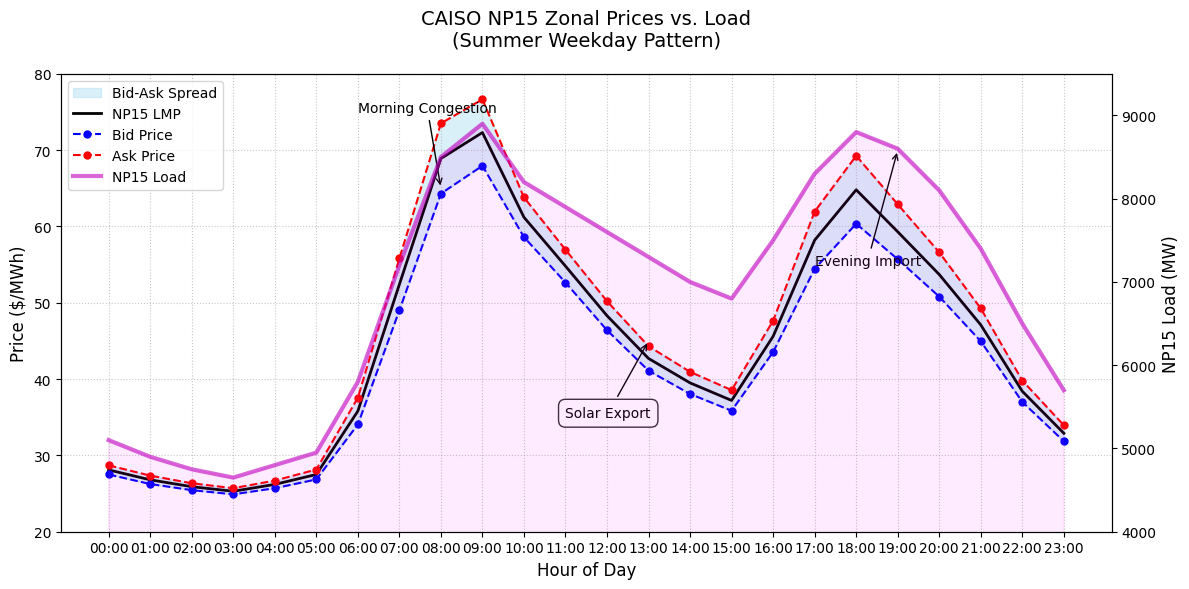

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Configure realistic CAISO patterns for NP15 zone
np.random.seed(42)
hours = 24
timestamps = [datetime(2024,7,1,0,0,0) + timedelta(hours=i) for i in range(hours)]

# Base LMP pattern (NP15 summer weekday)
base_prices = np.array([
    28.1, 26.8, 25.9, 25.3, 26.2, 27.5,  # Overnight (12AM-5AM)
    35.8, 52.4, 68.9, 72.3,  # Morning ramp (6AM-9AM)
    61.2, 54.8, 48.3, 42.7, 39.5, 37.2,  # Midday solar (10AM-3PM)
    45.6, 58.2, 64.8, 59.3, 53.7, 47.1,  # Evening peak (4PM-9PM)
    38.4, 32.9  # Night fall (10PM-11PM)
])

# NP15 zonal load in MW (typical summer day)
zone_load_mw = np.array([
    5100, 4900, 4750, 4650, 4800, 4950,  # Night
    5800, 7200, 8500, 8900,  # Morning
    8200, 7900, 7600, 7300, 7000, 6800,  # Midday
    7500, 8300, 8800, 8600, 8100, 7400,  # Evening
    6500, 5700  # Night
])

# Dynamic spreads
spreads = np.array([
    1.2, 1.1, 0.9, 0.8, 1.0, 1.3,  # Night
    3.5, 6.8, 9.2, 8.7,  # Morning
    5.2, 4.3, 3.8, 3.2, 2.9, 2.7,  # Midday
    4.1, 7.5, 8.9, 7.2, 5.8, 4.3,  # Evening
    2.8, 2.1  # Night
])

# Create DataFrame
df2 = pd.DataFrame({
    'Hour': [ts.strftime('%H:%M') for ts in timestamps],
    'Buy_Price': np.round(base_prices - spreads/2, 2),
    'Sell_Price': np.round(base_prices + spreads/2, 2),
    'LMP': base_prices,
    'Spread': spreads,
    'NP15_Load_MW': zone_load_mw
}).set_index('Hour')

# Create figure with dual axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Price data (left axis)
ax1.fill_between(df2.index, df2['Buy_Price'], df2['Sell_Price'], 
                color='skyblue', alpha=0.3, label='Bid-Ask Spread')
ax1.plot(df2.index, df2['LMP'], 'k-', linewidth=2, label='NP15 LMP')
ax1.plot(df2.index, df2['Buy_Price'], 'b.--', markersize=10, label='Bid Price')
ax1.plot(df2.index, df2['Sell_Price'], 'r.--', markersize=10, label='Ask Price')
ax1.set_ylabel('Price ($/MWh)', fontsize=12)
ax1.set_ylim(20, 80)

# Load data (right axis)
ax2 = ax1.twinx()
ax2.plot(df2.index, df2['NP15_Load_MW'], 'm-', linewidth=3, alpha=0.6, 
         label='NP15 Load')
ax2.fill_between(df2.index, df2['NP15_Load_MW'], alpha=0.08, color='magenta')
ax2.set_ylabel('NP15 Load (MW)', fontsize=12)
ax2.set_ylim(4000, 9500)

# Formatting
plt.title('CAISO NP15 Zonal Prices vs. Load\n(Summer Weekday Pattern)', 
         fontsize=14, pad=20)
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Annotate zonal dynamics
ax1.annotate('Morning Congestion', ('08:00', 65), xytext=('06:00', 75),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax1.annotate('Solar Export', ('13:00', 45), xytext=('11:00', 35),
            arrowprops=dict(arrowstyle='->'), fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
ax1.annotate('Evening Import', ('19:00', 70), xytext=('17:00', 55),
            arrowprops=dict(arrowstyle='->'), fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()

# Display
print("CAISO NP15 Zonal Market Data:")
plt.show()

Original Data (MWh/MW):


,Buy_Price,Sell_Price,LMP,Spread,NP15_Load_MW
Hour,,,,,
00:00,27.50,28.70,28.1,1.2,5100
01:00,26.25,27.35,26.8,1.1,4900
02:00,25.45,26.35,25.9,0.9,4750



Converted Data (kWh/kW):


C:\Users\ismae\AppData\Local\Temp\ipykernel_22948\2451160569.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(df_k.head(3).applymap(lambda x: f"{x:.5f}" if isinstance(x, float) else x))


,Buy_Price,Sell_Price,LMP,Spread,NP15_Load_kW,Projected_Load_kW
Hour,,,,,,
00:00,0.02750,0.02870,0.02810,0.00120,5100000,5100
01:00,0.02625,0.02735,0.02680,0.00110,4900000,4900
02:00,0.02545,0.02635,0.02590,0.00090,4750000,4750


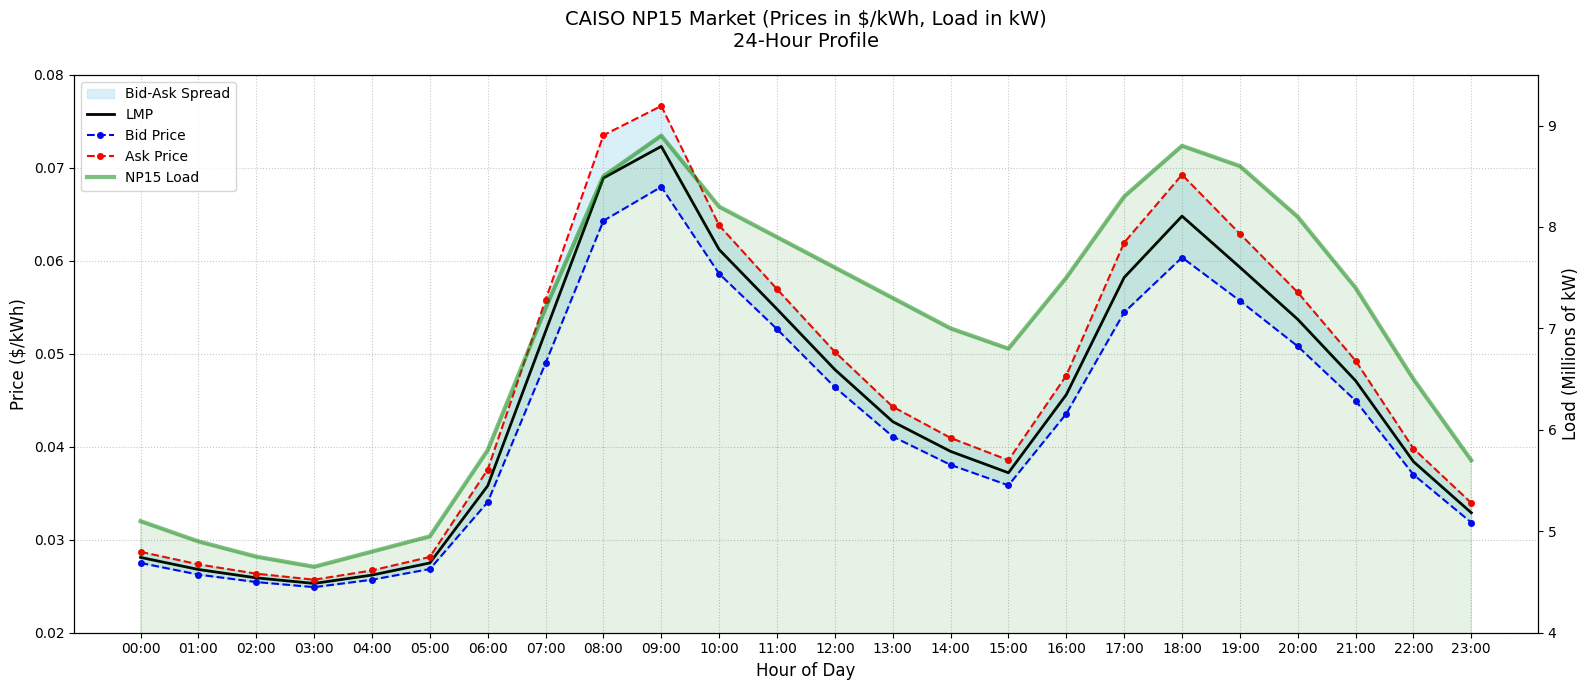

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Your original data
data = {
    'Buy_Price': [27.50,26.25,25.45,24.90,25.70,26.85,34.05,49.00,64.30,67.95,58.60,52.65,46.40,41.10,38.05,35.85,43.55,54.45,60.35,55.70,50.80,44.95,37.00,31.85],
    'Sell_Price': [28.70,27.35,26.35,25.70,26.70,28.15,37.55,55.80,73.50,76.65,63.80,56.95,50.20,44.30,40.95,38.55,47.65,61.95,69.25,62.90,56.60,49.25,39.80,33.95],
    'LMP': [28.1,26.8,25.9,25.3,26.2,27.5,35.8,52.4,68.9,72.3,61.2,54.8,48.3,42.7,39.5,37.2,45.6,58.2,64.8,59.3,53.7,47.1,38.4,32.9],
    'Spread': [1.2,1.1,0.9,0.8,1.0,1.3,3.5,6.8,9.2,8.7,5.2,4.3,3.8,3.2,2.9,2.7,4.1,7.5,8.9,7.2,5.8,4.3,2.8,2.1],
    'NP15_Load_MW': [5100,4900,4750,4650,4800,4950,5800,7200,8500,8900,8200,7900,7600,7300,7000,6800,7500,8300,8800,8600,8100,7400,6500,5700]
}

# Create DataFrame
df3 = pd.DataFrame(data, index=pd.Index([f"{h:02d}:00" for h in range(24)], name='Hour'))

# Convert units
df_k = pd.DataFrame({
    'Buy_Price': df3['Buy_Price'] / 1000,  # $/MWh → $/kWh
    'Sell_Price': df3['Sell_Price'] / 1000,
    'LMP': df3['LMP'] / 1000,
    'Spread': df3['Spread'] / 1000,
    'NP15_Load_kW': df3['NP15_Load_MW'] * 1000,  # MW → kW
    'Projected_Load_kW': df3['NP15_Load_MW']  # MW → kW
})

# Create plot
fig, ax1 = plt.subplots(figsize=(16, 7))

# Price data (left axis)
ax1.fill_between(df_k.index, df_k['Buy_Price'], df_k['Sell_Price'], 
                color='skyblue', alpha=0.3, label='Bid-Ask Spread')
ax1.plot(df_k.index, df_k['LMP'], 'k-', linewidth=2, label='LMP')
ax1.plot(df_k.index, df_k['Buy_Price'], 'b.--', markersize=8, label='Bid Price')
ax1.plot(df_k.index, df_k['Sell_Price'], 'r.--', markersize=8, label='Ask Price')
ax1.set_ylabel('Price ($/kWh)', fontsize=12)
ax1.set_ylim(0.02, 0.08)

# Load data (right axis)
ax2 = ax1.twinx()
ax2.plot(df_k.index, df_k['NP15_Load_kW']/1e6, 'g-', linewidth=3, alpha=0.5,  # Display in millions of kW
         label='NP15 Load')
ax2.fill_between(df_k.index, df_k['NP15_Load_kW']/1e6, alpha=0.1, color='green')
ax2.set_ylabel('Load (Millions of kW)', fontsize=12)
ax2.set_ylim(4, 9.5)

# Formatting
plt.title('CAISO NP15 Market (Prices in $/kWh, Load in kW)\n24-Hour Profile', 
         fontsize=14, pad=20)
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()

# Display DataFrames
print("Original Data (MWh/MW):")
display(df3.head(3))
print("\nConverted Data (kWh/kW):")
display(df_k.head(3).applymap(lambda x: f"{x:.5f}" if isinstance(x, float) else x))

plt.show()

In [12]:
# Create desired output DataFrame
output_df = pd.DataFrame({
    "timestamp": df_k.index,
    "excess_capacity(kW)": (K - df_k["Projected_Load_kW"]).astype(int)
})
output_df

,timestamp,excess_capacity(kW)
Hour,,
00:00,00:00,4900
01:00,01:00,5100
02:00,02:00,5250
03:00,03:00,5350
04:00,04:00,5200
05:00,05:00,5050
06:00,06:00,4200
07:00,07:00,2800
08:00,08:00,1500


# Create problem variables

In [13]:
my_bit_charging_indicator_array = BitArrayShape(name='charging_array', shape=(df_bat['Quantity'].sum(),T), axis_names=['battery','interval'])
my_bit_discharging_indicator_array = BitArrayShape(name='discharging_array', shape=(df_bat['Quantity'].sum(),T), axis_names=['battery','interval'])

## Slack Variables

##### 1) Slack for consecutive charging and discharging: No consecutive charging or discharging up to 3 periods

In [14]:
slack_consec_charg_list = []

for i in range(num_batteries):
    slack_var_name = f"slack_consec_charge_battery_{i}"
    slack_consec_charg_list.append(VarSlack(name=slack_var_name,start=0,step=1,stop=3,slack_type=SlackType.binary))


slack_consec_discharg_list = []

for i in range(num_batteries):
    slack_var_name = f"slack_consec_discharge_battery_{i}"
    slack_consec_discharg_list.append(VarSlack(name=slack_var_name,start=0,step=1,stop=3,slack_type=SlackType.binary))

In [15]:
my_varshapeset = VarShapeSet(my_bit_charging_indicator_array,
                             my_bit_discharging_indicator_array,
                             *slack_consec_charg_list,
                             *slack_consec_discharg_list)

## Constraints

##### 1) Exclusivity (HARD): No charging and discharging at the same time

In [16]:
H_exclusive = BinPol(my_varshapeset)

for i in range(num_batteries):
    for t in range(T):
        H_exclusive.add_term(1, (("charging_array", i, t), ("discharging_array", i, t)))

# Now normalization works
H_exclusive_normalized = H_exclusive * (1 / (num_batteries * T))

##### 2) Consecutive charging/discharging (SOFT): No consecutive charging and discharging periods

In [17]:
H_consec_charging = BinPol(my_varshapeset)

for i in range(num_batteries):
    
    H_consec_sub_char = BinPol(my_varshapeset)
    
    for t in range(T - 3):
        
        H_consec_sub_char.add_term(1, (("charging_array", i, t),))
        H_consec_sub_char.add_term(1, (("charging_array", i, t+1),))
        H_consec_sub_char.add_term(1, (("charging_array", i, t+2),))

    # Build the quadratic penalty
    H_consec_charging += ((H_consec_sub_char - 2).add_variable('slack_consec_charge_battery_'+str(i))) ** 2

H_consec_charging *= 1 / (num_batteries * (T - 2))

In [18]:
H_consec_discharging = BinPol(my_varshapeset)

for i in range(num_batteries):
    
    H_consec_sub_dischar = BinPol(my_varshapeset)
    
    for t in range(T - 3):
        
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t),))
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t+1),))
        H_consec_sub_dischar.add_term(1, (("discharging_array", i, t+2),))

    # Build the quadratic penalty
    H_consec_discharging += ((H_consec_sub_dischar - 2).add_variable('slack_consec_discharge_battery_'+str(i))) ** 2

H_consec_discharging *= 1 / (num_batteries * (T - 2))

##### 3) Transformer capacity limit (HARD)

In [19]:
H_transformer_capacity = BinPol(my_varshapeset)

scale_factor = float(output_df['excess_capacity(kW)'].max())

for t in range(T):
    H_sub = BinPol(my_varshapeset)
    
    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        H_sub.add_term(eff_c * charge_rate, (("charging_array", i, t),))
        H_sub.add_term(-1/eff_d * discharge_rate, (("discharging_array", i, t),))

    Kt = float(output_df.iloc[t]['excess_capacity(kW)'])  #### Kt = Lt - K

    H_transformer_capacity += (H_sub - Kt) ** 2

# Normalize after summation
H_transformer_capacity_normalized = H_transformer_capacity * (1 / scale_factor**2)

In [20]:
df_k

,Buy_Price,Sell_Price,LMP,Spread,NP15_Load_kW,Projected_Load_kW
Hour,,,,,,
00:00,0.02750,0.02870,0.0281,0.0012,5100000,5100
01:00,0.02625,0.02735,0.0268,0.0011,4900000,4900
02:00,0.02545,0.02635,0.0259,0.0009,4750000,4750
03:00,0.02490,0.02570,0.0253,0.0008,4650000,4650
04:00,0.02570,0.02670,0.0262,0.0010,4800000,4800
05:00,0.02685,0.02815,0.0275,0.0013,4950000,4950
06:00,0.03405,0.03755,0.0358,0.0035,5800000,5800
07:00,0.04900,0.05580,0.0524,0.0068,7200000,7200
08:00,0.06430,0.07350,0.0689,0.0092,8500000,8500


In [21]:
T

24

## Objective(s)

##### 1) Maximize profit versus loss

In [22]:
# Estimate max value
max_main = 0.0
for i in range(num_batteries):
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    for t in range(T):
        max_main += max(abs(eff_c * charge_rate), abs(eff_d * discharge_rate))

# Build and normalize H_main
H_main = BinPol(my_varshapeset)
for i in range(num_batteries):
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    for t in range(T):
        buy_price = df_k.iloc[t]['Buy_Price']
        sell_price = df_k.iloc[t]['Sell_Price']
        H_main.add_term(eff_c * charge_rate * buy_price, (("charging_array", i, t),))
        H_main.add_term(-1/eff_d * discharge_rate * sell_price, (("discharging_array", i, t),))

# Normalize and scale
H_main_normalized = (H_main / max_main)

##### 2) Maximize user satisfaction

In [23]:
H_energy_tracking = BinPol(my_varshapeset)


for i in range(num_batteries):
    
    E_o_i = df_expanded.iloc[i]['E_initial(kWh)']
    E_r_i = df_expanded.iloc[i]['E_required(kWh)']
    eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
    eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
    charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
    discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']
    
    H_energy_i_t = BinPol(my_varshapeset)

    E_diff = float(E_o_i - E_r_i)
    
    for t in range(T):
        
        # Add cumulative sum from v=0 to t
        for v in range(t + 1):
            
            H_energy_i_t.add_term(eff_c * charge_rate, (("charging_array", i, v),))
            H_energy_i_t.add_term(-1/eff_d * discharge_rate, (("discharging_array", i, v),))

        # Square the deviation
    H_energy_tracking += (H_energy_i_t + E_diff) ** 2


E_initial = list(df_expanded['E_initial(kWh)'])
E_required = list(df_expanded['E_required(kWh)'])

scale_E = max(abs(np.array(E_initial) - np.array(E_required))) + 1  # Add 1 to avoid div/0
H_energy_tracking_normalized = H_energy_tracking * (1 / (scale_E**2 * T * num_batteries))

##### 3) Minimize Peak-Valley control minimization

In [24]:
# H_net_load = BinPol(my_varshapeset)  # Objective: Minimize net transformer load (after DER actions)

# scale_net_load = df_k['Projected_Load_kW'].max() + 1  # To normalize

# for t in range(T):
    
#     H_t = BinPol(my_varshapeset)

#     L_t = float(df_k.iloc[t]['Projected_Load_kW'])  # Forecasted grid load

#     for i in range(num_batteries):
        
#         eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
#         eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
#         charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
#         discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

#         # Add charge to load
#         H_t.add_term(eff_c * charge_rate, (("charging_array", i, t),))

#         # Subtract discharge from load
#         H_t.add_term(-discharge_rate / eff_d, (("discharging_array", i, t),))

#     # Penalize total load at time t
#     H_net_load += ((H_t + L_t) * (1 / scale_net_load)) ** 2

In [25]:
# H_net_load_variance = BinPol(my_varshapeset)
# L_avg = BinPol(my_varshapeset)  # symbolic average load

# # Step 1: Build symbolic average load
# for t in range(T):
    
#     L_t = float(df_k.iloc[t]['Projected_Load_kW'])

#     L_avg += L_t / T  # base load

#     for i in range(num_batteries):
#         eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
#         eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
#         charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
#         discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

#         L_avg.add_term(eff_c * charge_rate / T, (("charging_array", i, t),))
#         L_avg.add_term(-discharge_rate / (eff_d * T), (("discharging_array", i, t),))

# # Step 2: Penalize deviation from symbolic average
# gamma = df_k['Projected_Load_kW'].max() + 1

# for t in range(T):
    
#     H_t = BinPol(my_varshapeset)
#     L_t = float(df_k.iloc[t]['Projected_Load_kW'])

#     H_t += L_t

#     for i in range(num_batteries):
        
#         eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
#         eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
#         charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
#         discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

#         H_t.add_term(eff_c * charge_rate, (("charging_array", i, t),))
#         H_t.add_term(-discharge_rate / eff_d, (("discharging_array", i, t),))

#     # Variance penalty: (NetLoad_t - AvgLoad)^2
#     # H_net_load_variance += ((H_t - L_avg) * (1 / gamma)) ** 2
#     H_net_load_variance += ((H_t) * (1 / gamma)) ** 2

In [26]:
H_net_load_variance = BinPol(my_varshapeset)
L_avg = BinPol(my_varshapeset)

# 1. Build symbolic average load
for t in range(T):
    L_t = float(df_k.iloc[t]['Projected_Load_kW'])
    L_avg += L_t / T

    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        L_avg.add_term(eff_c * charge_rate / T, (("charging_array", i, t),))
        L_avg.add_term(-discharge_rate / (eff_d * T), (("discharging_array", i, t),))

# 2. Penalize deviation from average
gamma = df_k['Projected_Load_kW'].max() + 1

for t in range(T):
    H_t = BinPol(my_varshapeset)
    L_t = float(df_k.iloc[t]['Projected_Load_kW'])
    
    H_t += L_t
    for i in range(num_batteries):
        eff_c = df_expanded.iloc[i]['C_eff(%)'] / 100.0
        eff_d = df_expanded.iloc[i]['D_eff(%)'] / 100.0
        charge_rate = df_expanded.iloc[i]['Charging_rate(kW)']
        discharge_rate = df_expanded.iloc[i]['Dicharging_rate(kW)']

        H_t.add_term(eff_c * charge_rate, (("charging_array", i, t),))
        H_t.add_term(-discharge_rate / eff_d, (("discharging_array", i, t),))

    H_net_load_variance += ((H_t - L_avg) * (1 / gamma)) ** 2

## Executing

In [27]:
### Constuimos la función de coste con el término principal y todas las constraints:

# lambda_main1 = 50
# lambda_main2 = 400
# lambda_main3 = 200
# lambda_exclusivity = 10
# lambda_consec_char = 1
# lambda_consec_dischar = 1
# lambda_transf = 5

# cost_function = (lambda_main1*H_main_normalized +
#                 lambda_main2*H_energy_tracking_normalized +
#                 lambda_main3*H_net_load +
#                 lambda_exclusivity*H_exclusive_normalized +
#                 lambda_consec_char*H_consec_charging +
#                 lambda_consec_dischar*H_consec_discharging +
#                 lambda_transf*H_transformer_capacity_normalized)

In [28]:
lambda_main1 = 10
lambda_main2 = 200
lambda_main3 = 200
lambda_exclusivity = 10
lambda_consec_char = 1
lambda_consec_dischar = 1
lambda_transf = 5

cost_function = (lambda_main1*H_main_normalized +
                lambda_main2*H_energy_tracking_normalized +
                lambda_main3*H_net_load_variance +
                lambda_exclusivity*H_exclusive_normalized +
                lambda_consec_char*H_consec_charging +
                lambda_consec_dischar*H_consec_discharging +
                lambda_transf*H_transformer_capacity_normalized)

In [29]:
from dadk.QUBOSolverCPU import *

start_time = time.time()

solver = QUBOSolverCPU(
number_iterations=500000,
number_runs=100,
scaling_bit_precision=32,
auto_tuning=AutoTuning.AUTO_SCALING_AND_SAMPLING)

solution_list = solver.minimize(cost_function)

solution = solution_list.get_minimum_energy_solution()

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time:.4f} seconds")


********************************************************************************
  temperature_start:                       4.15557118e-01
  temperature_end:                         8.64347287e-02
  offset_increase_rate:                    2.13391276e-01
  duration:                                0.319 sec
********************************************************************************

  max_abs_coefficient:                    123.587

********************************************************************************
Effective values (including scaling factor)
  scaling_factor:                           1.73746050e+07
  temperature_start:                        7.22014078e+06
  temperature_end:                          1.50176927e+06
  offset_increase_rate:                     3.70758913e+06
  duration:                                 0.183 sec
********************************************************************************

Elapsed time: 1216.7091 seconds


In [30]:
my_bit_charging_array = solution.extract_bit_array("charging_array")
my_bit_discharging_array = solution.extract_bit_array("discharging_array")

In [31]:
print(f"Elapsed time: {elapsed_time/60:.4f} minutes")

Elapsed time: 20.2785 minutes


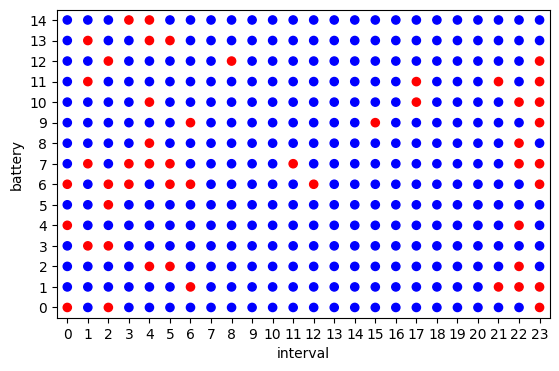

In [32]:
my_bit_charging_array.draw(order=[1,0])

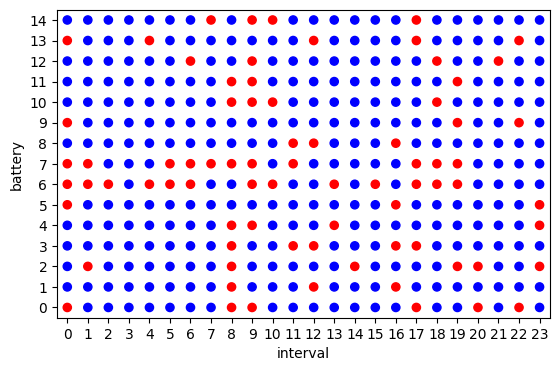

In [33]:
my_bit_discharging_array.draw(order=[1,0])

In [34]:
discharging_array = my_bit_discharging_array.data
discharging_array[discharging_array == 1] = -1
# discharging_array

In [35]:
charging_array = my_bit_charging_array.data
# charging_array

In [36]:
array1 = discharging_array
array2 = charging_array

# Create mask where condition is true: -1 in array1 and 1 in array2
mask_conflict = (array1 == -1) & (array2 == 1)

# Start by copying array1
result = array1.copy()

# Set conflict positions to 0
result[mask_conflict] = 0

# Where array1 is 0, take value from array2
mask_array1_zero = (array1 == 0)
result[mask_array1_zero] = array2[mask_array1_zero]

# result

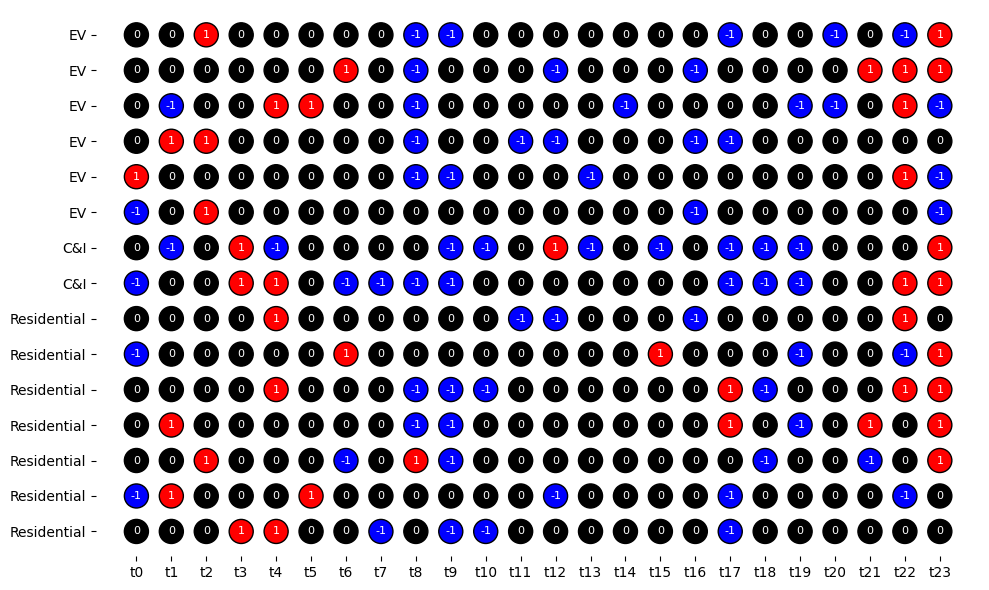

In [37]:
# Labels
row_labels = list(df_expanded['Type'])
col_labels = ['t' + str(t) for t in range(T)]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Get coordinates for each value
rows, cols = np.indices(result.shape)

# Flatten for plotting
x = cols.flatten()
y = rows.flatten()
values = result.flatten()

# Map values to colors
color_map = {0: 'black', 1: 'red', -1: 'blue'}
colors = [color_map[val] for val in values]

# Scatter plot
ax.scatter(x, y, c=colors, s=300, marker='o', edgecolors='k')

# Set ticks and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Invert y-axis to match matrix layout
ax.invert_yaxis()

# Remove grid and axis frame
ax.grid(False)
ax.set_frame_on(False)

# Optionally: Add value annotations
for i, val in enumerate(values):
    ax.text(x[i], y[i], str(val), color='white', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Constraint satisfiability assessment

#### Constraint 1: Exclusivity (HARD -No charging and discharging at the same time-)

In [38]:
# Element-wise multiplication
product = my_bit_charging_array.data * my_bit_discharging_array.data

# Find indices where the result is 1
indices = np.argwhere(product == 1)

# Print result
error = 0
for row, col in indices:
    error += 1 
    print(f"Match at battery {row}, time period {col}")

if error == 0:
    print(f'Constraint -No charging and discharging at the same time- satisfied')
else:
    print(f'Constraint -No charging and discharging at the same time- NOT satisfied')

Constraint -No charging and discharging at the same time- satisfied


#### Constraint 2: Consecutive charging/discharging (SOFT -No consecutive charging and discharging periods-)

In [39]:
arr = my_bit_charging_array.data

# Function to check for 3+ consecutive 1s in a binary row
def has_three_consecutive_ones(row):
    return any(np.convolve(row, np.ones(3, dtype=int), mode='valid') == 3)

# Apply row-wise
consecutive_flags = np.apply_along_axis(has_three_consecutive_ones, axis=1, arr=arr)

# Print results
for i, flag in enumerate(consecutive_flags):
    print(f"Battery {i} with 3 or more consecutive charging events: {'YES' if flag else 'NO'}")


arr = my_bit_discharging_array.data

# Function to check for 3+ consecutive 1s in a binary row
def has_three_consecutive_ones(row):
    return any(np.convolve(row, np.ones(3, dtype=int), mode='valid') == 3)

# Apply row-wise
consecutive_flags = np.apply_along_axis(has_three_consecutive_ones, axis=1, arr=arr)

# Print results
for i, flag in enumerate(consecutive_flags):
    print(f"Battery {i} with 3 or more consecutive discharging events: {'YES' if flag else 'NO'}")

Battery 0 with 3 or more consecutive charging events: NO
Battery 1 with 3 or more consecutive charging events: YES
Battery 2 with 3 or more consecutive charging events: NO
Battery 3 with 3 or more consecutive charging events: NO
Battery 4 with 3 or more consecutive charging events: NO
Battery 5 with 3 or more consecutive charging events: NO
Battery 6 with 3 or more consecutive charging events: NO
Battery 7 with 3 or more consecutive charging events: YES
Battery 8 with 3 or more consecutive charging events: NO
Battery 9 with 3 or more consecutive charging events: NO
Battery 10 with 3 or more consecutive charging events: NO
Battery 11 with 3 or more consecutive charging events: NO
Battery 12 with 3 or more consecutive charging events: NO
Battery 13 with 3 or more consecutive charging events: NO
Battery 14 with 3 or more consecutive charging events: NO
Battery 0 with 3 or more consecutive discharging events: NO
Battery 1 with 3 or more consecutive discharging events: NO
Battery 2 with 3 o

#### Constraint 3: Transformer capacity limit (HARD - Total load [=exogenous + batteries operations] must not exceed a transformer capacity-)

In [40]:
df_expanded

,Type,Quantity,Capacity(kWh),Charging_rate(kW),Dicharging_rate(kW),C_eff(%),D_eff(%),E_initial(kWh),E_required(kWh)
0,EV,1,200,20,10,90,90,100,60
1,EV,1,200,20,10,90,90,100,60
2,EV,1,200,20,10,90,90,100,60
3,EV,1,200,20,10,90,90,100,60
4,EV,1,200,20,10,90,90,100,60
5,EV,1,200,20,10,90,90,100,60
6,C&I,1,2000,200,100,90,90,1000,600
7,C&I,1,2000,200,100,90,90,1000,600
8,Residential,1,20,10,5,90,90,10,6
9,Residential,1,20,10,5,90,90,10,6


In [41]:
output_df

,timestamp,excess_capacity(kW)
Hour,,
00:00,00:00,4900
01:00,01:00,5100
02:00,02:00,5250
03:00,03:00,5350
04:00,04:00,5200
05:00,05:00,5050
06:00,06:00,4200
07:00,07:00,2800
08:00,08:00,1500


In [42]:
arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge #### It's a plus because result_discharge is already negative

balance_charge_discharge

# Compute column sums
col_sums = balance_charge_discharge.sum(axis=0)

thresholds = list(output_df['excess_capacity(kW)'])

# Compare each column sum to the corresponding threshold
exceeds = col_sums > thresholds

# Print results
print("Batteries power exchange balance (kW):", list(col_sums))
print("Thresholds (kW):", thresholds)
print("Exceeds?   :", list(exceeds))

Batteries power exchange balance (kW): [9.0, 27.0, 153.0, 369.0, 139.5, 207.0, 22.5, -94.5, -135.0, -216.0, -99.0, 76.5, 153.0, -99.0, -9.0, -81.0, -31.5, -189.0, -189.0, -198.0, -18.0, 22.5, 234.0, 405.0]
Thresholds (kW): [4900, 5100, 5250, 5350, 5200, 5050, 4200, 2800, 1500, 1100, 1800, 2100, 2400, 2700, 3000, 3200, 2500, 1700, 1200, 1400, 1900, 2600, 3500, 4300]
Exceeds?   : [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]


In [43]:
# balance_charge_discharge

#### Constraint 4: Final SOC ≥ 30% of Capacity (SOFT -Final required stored energy per battery must be ≥ 30% of battery Capacity for emergency cases and or range anxiety-)

###### Assumptions:

1) Each battery is full at the start of the trading window, hence Initial energy per battery is equal to battery capacity

2) Final energy stored in each battery should be equal or larger than 30% of total capacity

3) Each trading interval corresponds to one hour, hence At = 1

In [44]:
# df_expanded

In [45]:
full_capacities = list(df_expanded['Capacity(kWh)'].astype(int))

initial_energy = list(df_expanded['E_initial(kWh)'].astype(int))

final_energy = list(df_expanded['E_required(kWh)'].astype(int))

At = 1 ### Trading interval corresponds to one hour

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]

d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge ### It's a plus because result_discharge is already negative

balance_charge_discharge

# Compute rows sums
row_sums = balance_charge_discharge.sum(axis=1)

energy_balance_per_battery = list(At * row_sums)

energy_balance_per_battery

balance_ini_minus_exch = [(initial_energy[i] + energy_balance_per_battery[i]) for i in range (len(energy_balance_per_battery))]

# Print the elements where list1 is NOT greater than list2
for i, (a, b) in enumerate(zip(balance_ini_minus_exch, final_energy)):
    if not a > b:
        print(f"False at battery {i} where Final SOC ≥ 30% not met: list1[{i}] = {a}, list2[{i}] = {b}")
    else:
        print(f"Battery {i} meets Final SOC ≥ 30%")        

Battery 0 meets Final SOC ≥ 30%
Battery 1 meets Final SOC ≥ 30%
Battery 2 meets Final SOC ≥ 30%
Battery 3 meets Final SOC ≥ 30%
Battery 4 meets Final SOC ≥ 30%
Battery 5 meets Final SOC ≥ 30%
Battery 6 meets Final SOC ≥ 30%
Battery 7 meets Final SOC ≥ 30%
Battery 8 meets Final SOC ≥ 30%
Battery 9 meets Final SOC ≥ 30%
Battery 10 meets Final SOC ≥ 30%
Battery 11 meets Final SOC ≥ 30%
Battery 12 meets Final SOC ≥ 30%
Battery 13 meets Final SOC ≥ 30%
Battery 14 meets Final SOC ≥ 30%


#### SOC evolution per battery

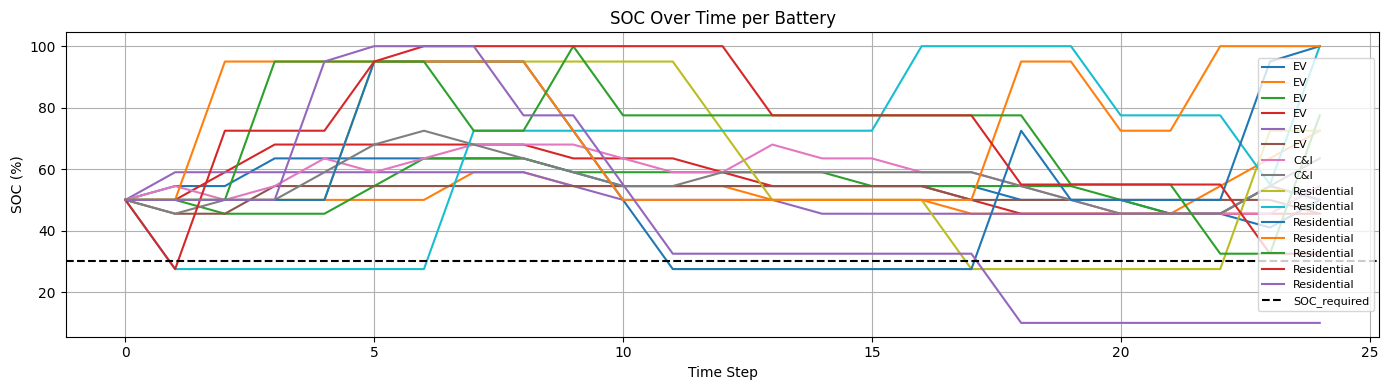

In [46]:
At = 1 ### Trading interval corresponds to one hour

Emax = list(df_expanded['Capacity(kWh)'])

battery_names = list(df_expanded['Type'])

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge


# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge #### It's a plus because result_discharge is already negative

energy_array = balance_charge_discharge

# Initial SOC for each battery
SOC_initial = np.ones(energy_array.shape[0])  # shape = (5,)
SOC_initial = np.array(list(df_expanded['E_initial(kWh)'].astype(int)))/Emax  # shape = (5,)

# Transpose energy_array to shape (time, battery)
energy_array = energy_array.T  # shape becomes (8, 5)

# Initialize SOC array (time+1 steps x batteries)
SOC = np.zeros((energy_array.shape[0] + 1, energy_array.shape[1]))
SOC[0] = SOC_initial

# Compute SOC over time
for t in range(energy_array.shape[0]):
    SOC[t + 1] = SOC[t] + energy_array[t] / Emax
    SOC[t + 1] = np.clip(SOC[t + 1], 0, 1)  # Keep within [0, 1]

# Plot
plt.figure(figsize=(14, 4))
for i, name in enumerate(battery_names):
    plt.plot(SOC[:, i] * 100, label=name)

# Add SOC_required line at 30%
plt.axhline(req_final_energy_perc, linestyle='--', color='black', label='SOC_required')
plt.xlabel("Time Step")
plt.ylabel("SOC (%)")
plt.title("SOC Over Time per Battery")
plt.grid(True)
plt.legend(fontsize=8)  # Smaller legend font
plt.tight_layout()
plt.show()

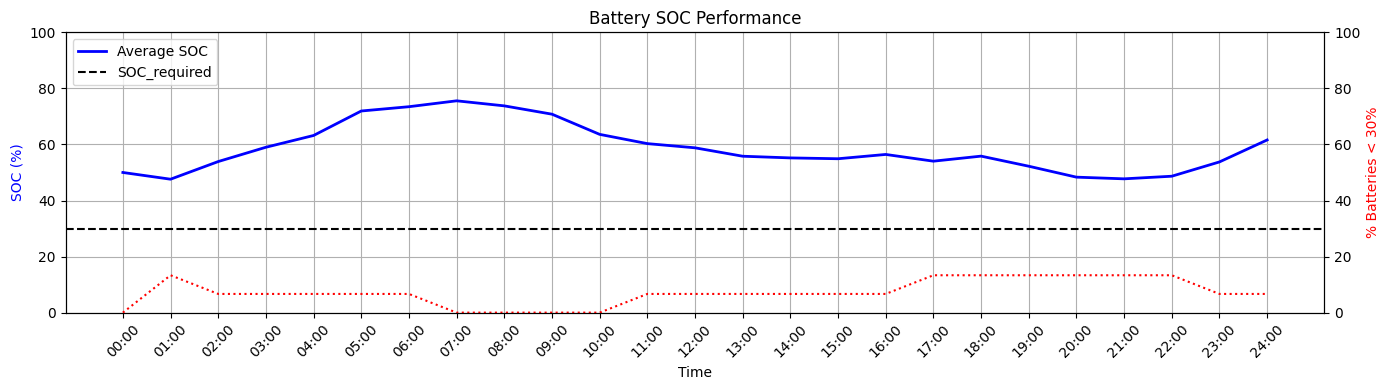

In [81]:
At = 1  # Trading interval corresponds to one hour

Emax = list(df_expanded['Capacity(kWh)'])
battery_names = list(df_expanded['Type'])

arr_charge = my_bit_charging_array.data
arr_discharge = my_bit_discharging_array.data

c_eff = list(df_expanded['C_eff(%)'])
c_rate = list(df_expanded['Charging_rate(kW)'])
c_eff_times_c_rate = [(c_eff[i]/100)*c_rate[i] for i in range(len(c_rate))]
d_eff = list(df_expanded['D_eff(%)'])
d_rate = list(df_expanded['Dicharging_rate(kW)'])
d_eff_times_d_rate = [(d_eff[i]/100)*d_rate[i] for i in range(len(d_rate))]

# Row multipliers
multipliers_charge = np.array(c_eff_times_c_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_charge = arr_charge * multipliers_charge

# Row multipliers
multipliers_discharge = np.array(d_eff_times_d_rate).reshape(-1, 1)  # shape (5, 1)
# Multiply each row
result_discharge = arr_discharge * multipliers_discharge

balance_charge_discharge = result_charge + result_discharge  # It's a plus because result_discharge is already negative

energy_array = balance_charge_discharge

# Initial SOC for each battery
SOC_initial = np.ones(energy_array.shape[0])  # shape = (5,)
SOC_initial = np.array(list(df_expanded['E_initial(kWh)'].astype(int)))/Emax  # shape = (5,)

# Transpose energy_array to shape (time, battery)
energy_array = energy_array.T  # shape becomes (8, 5)

# Initialize SOC array (time+1 steps x batteries)
SOC = np.zeros((energy_array.shape[0] + 1, energy_array.shape[1]))
SOC[0] = SOC_initial

# Compute SOC over time
for t in range(energy_array.shape[0]):
    SOC[t + 1] = SOC[t] + energy_array[t] / Emax
    SOC[t + 1] = np.clip(SOC[t + 1], 0, 1)  # Keep within [0, 1]

# Create time labels
time_labels = [f"{i:02d}:00" for i in range(len(SOC))]

# Calculate average SOC across all batteries
avg_SOC = np.mean(SOC, axis=1) * 100

# Calculate percentage of batteries below 30% for each time step
below_threshold = np.sum(SOC < (req_final_energy_perc/100), axis=1)
percentage_below = (below_threshold / SOC.shape[1]) * 100

# Create plot with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 4))

# Plot average SOC on primary axis
ax1.plot(avg_SOC, label='Average SOC', color='blue', linewidth=2)
ax1.axhline(req_final_energy_perc, linestyle='--', color='black', label='SOC_required')

# Set primary y-axis properties
ax1.set_xlabel("Time")
ax1.set_ylabel("SOC (%)", color='blue')
ax1.set_ylim(0, 100)
ax1.set_xticks(range(len(time_labels)))
ax1.set_xticklabels(time_labels, rotation=45)
ax1.grid(True)
ax1.legend(loc='upper left')

# Create secondary y-axis for percentage below threshold
ax2 = ax1.twinx()
ax2.plot(percentage_below, label='% Below Threshold', color='red', linestyle=':')
ax2.set_ylabel("% Batteries < 30%", color='red')
ax2.set_ylim(0, 100)

# Add title and adjust layout
plt.title("Battery SOC Performance")
fig.tight_layout()
plt.show()

In [48]:
# balance_charge_discharge

In [49]:
# df_expanded

#### Profit and Loss evolution (PnL)

In [50]:
df_k

,Buy_Price,Sell_Price,LMP,Spread,NP15_Load_kW,Projected_Load_kW
Hour,,,,,,
00:00,0.02750,0.02870,0.0281,0.0012,5100000,5100
01:00,0.02625,0.02735,0.0268,0.0011,4900000,4900
02:00,0.02545,0.02635,0.0259,0.0009,4750000,4750
03:00,0.02490,0.02570,0.0253,0.0008,4650000,4650
04:00,0.02570,0.02670,0.0262,0.0010,4800000,4800
05:00,0.02685,0.02815,0.0275,0.0013,4950000,4950
06:00,0.03405,0.03755,0.0358,0.0035,5800000,5800
07:00,0.04900,0.05580,0.0524,0.0068,7200000,7200
08:00,0.06430,0.07350,0.0689,0.0092,8500000,8500


In [51]:
df3

,Buy_Price,Sell_Price,LMP,Spread,NP15_Load_MW
Hour,,,,,
00:00,27.50,28.70,28.1,1.2,5100
01:00,26.25,27.35,26.8,1.1,4900
02:00,25.45,26.35,25.9,0.9,4750
03:00,24.90,25.70,25.3,0.8,4650
04:00,25.70,26.70,26.2,1.0,4800
05:00,26.85,28.15,27.5,1.3,4950
06:00,34.05,37.55,35.8,3.5,5800
07:00,49.00,55.80,52.4,6.8,7200
08:00,64.30,73.50,68.9,9.2,8500


In [52]:
# result_charge

In [53]:
prices_buy = np.array(list(df_k['Buy_Price']))

# Step 1: sum energy column-wise
total_energy_per_time_charge = At * result_charge.sum(axis=0)  # shape = (8,)

# Step 2: multiply element-wise by prices
weighted_energy_value_charge = total_energy_per_time_charge * prices_buy  # shape = (8,)

# Total revenue or cost
total_value_cost = weighted_energy_value_charge.sum()

# Output
print("Energy charged per timestamp (kWh):", total_energy_per_time_charge)
print("Price-weighted energy charged:", weighted_energy_value_charge)
print("Total cost: $", total_value_cost)


prices_sell = np.array(list(df_k['Sell_Price']))

# Step 1: sum energy column-wise
total_energy_per_time_discharge = At * (-1)*result_discharge.sum(axis=0)  # shape = (8,)

# Step 2: multiply element-wise by prices
weighted_energy_value_discharge = total_energy_per_time_discharge * prices_sell  # shape = (8,)

# Total revenue or cost
total_value_revenue = weighted_energy_value_discharge.sum()

# Output
print("Energy discharged per timestamp (kWh):", total_energy_per_time_discharge)
print("Price-weighted energy discharged:", weighted_energy_value_discharge)
print("Total revenue: $", total_value_revenue)


############# Balance Energy Exchange = (Energy discharged per timestamp (kWh)) - (Energy charged per timestamp (kWh))

BEE = total_energy_per_time_discharge - total_energy_per_time_charge
PnL = weighted_energy_value_discharge - weighted_energy_value_charge

df_k['Balance_discharged_charged(kWh)'] = BEE
df_k['PnL($/kWh)'] = PnL

Energy charged per timestamp (kWh): [216. 216. 243. 369. 234. 387. 207.   0.   9.   0.   0. 180. 180.   0.
   0.   9.   0.  18.   0.   0.   0.  27. 252. 432.]
Price-weighted energy charged: [ 5.94     5.67     6.18435  9.1881   6.0138  10.39095  7.04835  0.
  0.5787   0.       0.       9.477    8.352    0.       0.       0.32265
  0.       0.9801   0.       0.       0.       1.21365  9.324   13.7592 ]
Total cost: $ 94.44284999999999
Energy discharged per timestamp (kWh): [207.  189.   90.   -0.   94.5 180.  184.5  94.5 144.  216.   99.  103.5
  27.   99.    9.   90.   31.5 207.  189.  198.   18.    4.5  18.   27. ]
Price-weighted energy discharged: [ 5.9409    5.16915   2.3715   -0.        2.52315   5.067     6.927975
  5.2731   10.584    16.5564    6.3162    5.894325  1.3554    4.3857
  0.36855   3.4695    1.500975 12.82365  13.08825  12.4542    1.0188
  0.221625  0.7164    0.91665 ]
Total revenue: $ 124.94340000000001


In [54]:
df_k

,Buy_Price,Sell_Price,LMP,Spread,NP15_Load_kW,Projected_Load_kW,Balance_discharged_charged(kWh),PnL($/kWh)
Hour,,,,,,,,
00:00,0.02750,0.02870,0.0281,0.0012,5100000,5100,-9.0,0.000900
01:00,0.02625,0.02735,0.0268,0.0011,4900000,4900,-27.0,-0.500850
02:00,0.02545,0.02635,0.0259,0.0009,4750000,4750,-153.0,-3.812850
03:00,0.02490,0.02570,0.0253,0.0008,4650000,4650,-369.0,-9.188100
04:00,0.02570,0.02670,0.0262,0.0010,4800000,4800,-139.5,-3.490650
05:00,0.02685,0.02815,0.0275,0.0013,4950000,4950,-207.0,-5.323950
06:00,0.03405,0.03755,0.0358,0.0035,5800000,5800,-22.5,-0.120375
07:00,0.04900,0.05580,0.0524,0.0068,7200000,7200,94.5,5.273100
08:00,0.06430,0.07350,0.0689,0.0092,8500000,8500,135.0,10.005300


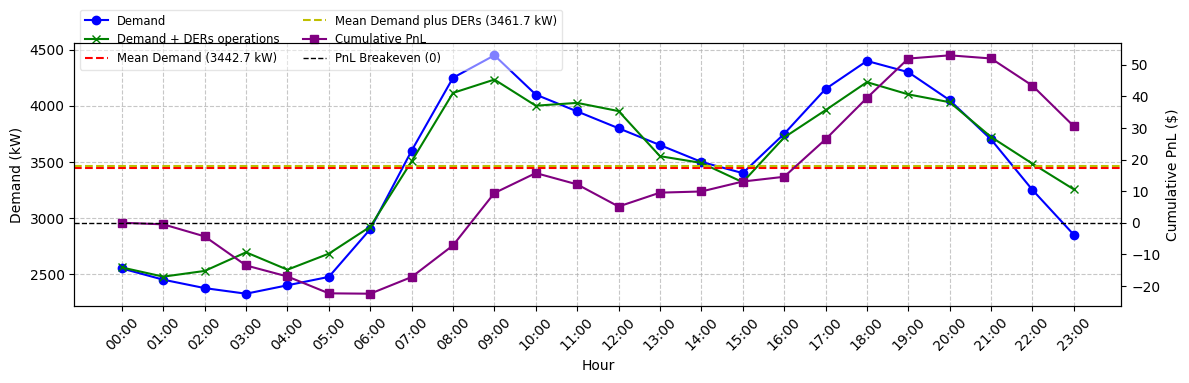

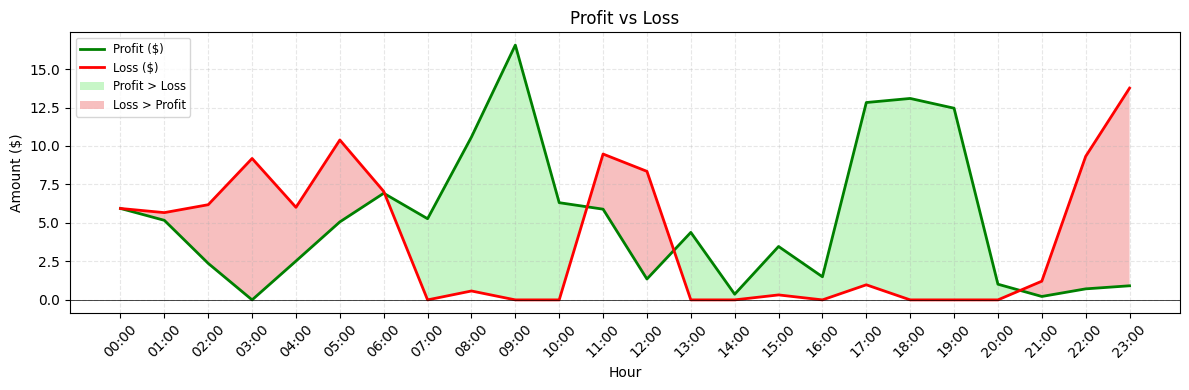

In [55]:
df_k1 = df_k.copy()
df_k1['Projected_Load_kW_1'] = (df_k1['Projected_Load_kW'] / 2).astype(int)
df_k1['Grid_to_DERs'] = total_energy_per_time_charge ### Charge
df_k1['DERs_to_Grid'] = total_energy_per_time_discharge ### Discharge
df_k1['Demand_plus_DERs'] = (df_k1['Projected_Load_kW_1'] + df_k1['Grid_to_DERs'] - df_k1['DERs_to_Grid']).astype(int)
df_k1['PnL_cum'] = np.cumsum(df_k1['PnL($/kWh)'])

df_k1['Profit ($)'] = weighted_energy_value_discharge
df_k1['Loss ($)'] = weighted_energy_value_charge


# Assuming your dataframe is named 'df'
# If not, replace 'df' with your dataframe name

# Extract the data
hours = df_k1.index  # Assuming the index is the hour
demand = df_k1['Projected_Load_kW_1']
demand_plus_ders = df_k1['Demand_plus_DERs']  # Note: There's a typo in your column name ('Demand' vs 'Demand')
mean_demand = demand.mean()
mean_demand_plus_ders = demand_plus_ders.mean()


# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 4))

# Plot Demand and Demand + DERs on primary axis (left)
ax1.plot(hours, demand, label='Demand', marker='o', color='blue')
ax1.plot(hours, demand_plus_ders, label='Demand + DERs operations', marker='x', color='green')
ax1.axhline(y=mean_demand, color='r', linestyle='--', label=f'Mean Demand ({mean_demand:.1f} kW)')
ax1.axhline(y=mean_demand_plus_ders, color='y', linestyle='--', label=f'Mean Demand plus DERs ({mean_demand_plus_ders:.1f} kW)')

# Customize primary axis
# ax1.set_title('Demand vs (Demand + DERs Operations) with Cumulative PnL')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Demand (kW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# Create secondary axis (right)
ax2 = ax1.twinx()
ax2.plot(hours, df_k1['PnL_cum'], label='Cumulative PnL', color='purple', linestyle='-', marker='s')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, label='PnL Breakeven (0)')  # <-- Added horizontal line at 0
ax2.set_ylabel('Cumulative PnL ($)')

# Combine legends from both axes with smaller font
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax1.legend(lines1 + lines2, labels1 + labels2, 
               loc='upper left',
               fontsize='small',    # Smaller font size
               framealpha=0.5,     # Slight transparency
               ncol=2,             # Two columns to save space
               bbox_to_anchor=(0, 1.15))  # Position above the plot

plt.tight_layout()
plt.show()

#######
#######

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 4))

# Plot the lines
ax.plot(hours, df_k1['Profit ($)'], label='Profit ($)', color='green', linewidth=2)
ax.plot(hours, df_k1['Loss ($)'], label='Loss ($)', color='red', linewidth=2)

# Fill between the lines with different colors
# Where Profit > Loss (positive area)
ax.fill_between(hours, 
                df_k1['Profit ($)'], 
                df_k1['Loss ($)'], 
                where=(df_k1['Profit ($)'] > df_k1['Loss ($)']),
                facecolor='lightgreen',
                alpha=0.5,
                interpolate=True,
                label='Profit > Loss')

# Where Loss > Profit (negative area)
ax.fill_between(hours, 
                df_k1['Profit ($)'], 
                df_k1['Loss ($)'], 
                where=(df_k1['Loss ($)'] > df_k1['Profit ($)']),
                facecolor='lightcoral',
                alpha=0.5,
                interpolate=True,
                label='Loss > Profit')

# Add zero line for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Customize the plot
ax.set_title('Profit vs Loss')
ax.set_xlabel('Hour')
ax.set_ylabel('Amount ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.legend(fontsize='small', framealpha=0.8)

plt.tight_layout()
plt.show()

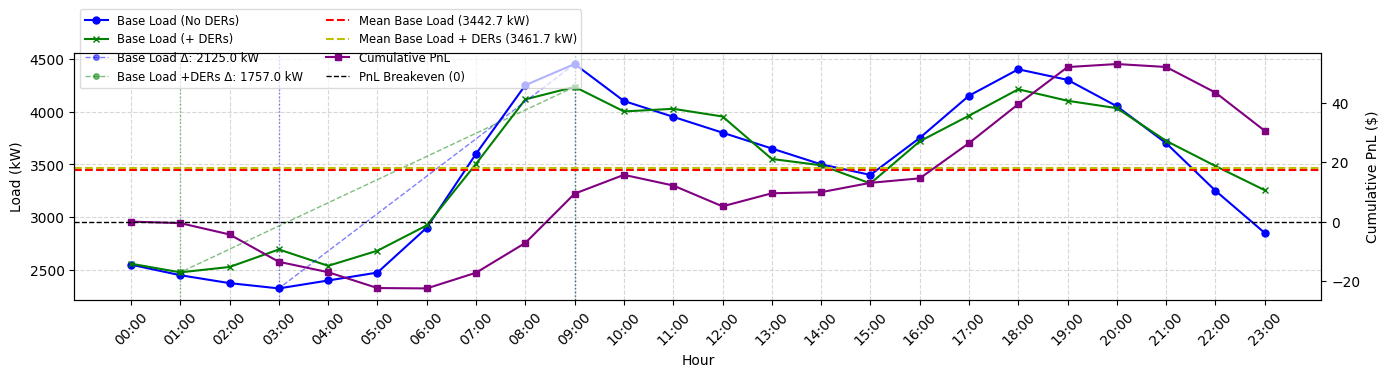

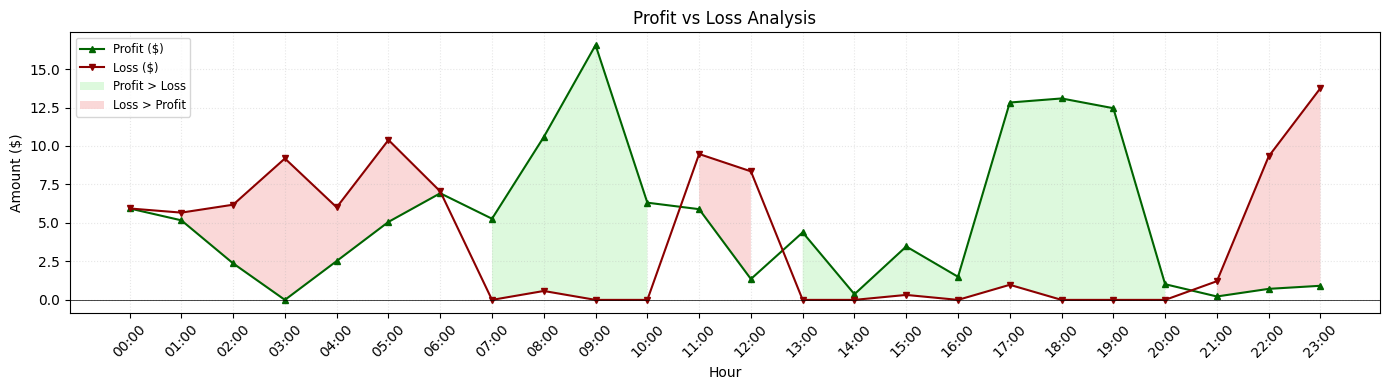

In [80]:
# Prepare the dataframe
df_k1 = df_k.copy()
df_k1['Projected_Load_kW_1'] = (df_k1['Projected_Load_kW'] / 2).astype(int)
df_k1['Grid_to_DERs'] = total_energy_per_time_charge  # Charge
df_k1['DERs_to_Grid'] = total_energy_per_time_discharge  # Discharge
df_k1['Demand_plus_DERs'] = (df_k1['Projected_Load_kW_1'] + df_k1['Grid_to_DERs'] - df_k1['DERs_to_Grid']).astype(int)
df_k1['PnL_cum'] = np.cumsum(df_k1['PnL($/kWh)'])
df_k1['Profit ($)'] = weighted_energy_value_discharge
df_k1['Loss ($)'] = weighted_energy_value_charge

# Extract the data
hours = df_k1.index
demand = df_k1['Projected_Load_kW_1']
demand_plus_ders = df_k1['Demand_plus_DERs']
mean_demand = demand.mean()
mean_demand_plus_ders = demand_plus_ders.mean()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 4))  # Increased height to accommodate legend

# Plot Demand and Demand + DERs on primary axis
ax1.plot(hours, demand, label='Base Load (No DERs)', marker='o', color='blue', markersize=5)
ax1.plot(hours, demand_plus_ders, label='Base Load (+ DERs)', marker='x', color='green', markersize=5)

# --- NEW PEAK/TRACK ANALYSIS ---
# Find peaks and troughs for Demand
demand_max_idx = demand.idxmax()
demand_min_idx = demand.idxmin()
demand_max_val = demand.max()
demand_min_val = demand.min()

# Find peaks and troughs for Demand + DERs
ders_max_idx = demand_plus_ders.idxmax()
ders_min_idx = demand_plus_ders.idxmin()
ders_max_val = demand_plus_ders.max()
ders_min_val = demand_plus_ders.min()

# Add vertical lines and difference indicators for Demand
ax1.axvline(x=demand_max_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=demand_min_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.plot([demand_max_idx, demand_min_idx], [demand_max_val, demand_min_val],
        'bo--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load Δ: {demand_max_val-demand_min_val:.1f} kW')

# Add vertical lines and difference indicators for Demand + DERs
ax1.axvline(x=ders_max_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=ders_min_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.plot([ders_max_idx, ders_min_idx], [ders_max_val, ders_min_val],
        'go--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load +DERs Δ: {ders_max_val-ders_min_val:.1f} kW')
# --- END NEW CODE ---

# Add mean reference lines
ax1.axhline(y=mean_demand, color='r', linestyle='--', label=f'Mean Base Load ({mean_demand:.1f} kW)')
ax1.axhline(y=mean_demand_plus_ders, color='y', linestyle='--', label=f'Mean Base Load + DERs ({mean_demand_plus_ders:.1f} kW)')

# Customize primary axis
ax1.set_xlabel('Hour')
ax1.set_ylabel('Load (kW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Create secondary axis
ax2 = ax1.twinx()
ax2.plot(hours, df_k1['PnL_cum'], label='Cumulative PnL', color='purple', linestyle='-', marker='s', markersize=5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, label='PnL Breakeven (0)')
ax2.set_ylabel('Cumulative PnL ($)')

# Combine and format legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
          loc='upper left',
          fontsize='small',
          framealpha=0.7,
          ncol=2,
          bbox_to_anchor=(0, 1.2))  # Adjusted for extra items

plt.tight_layout()
plt.show()

#############################################
# SECOND PLOT: Profit/Loss with filled areas #
#############################################

fig, ax = plt.subplots(figsize=(14, 4))

# Plot Profit/Loss lines
ax.plot(hours, df_k1['Profit ($)'], label='Profit ($)', color='darkgreen', linewidth=1.5, marker='^', markersize=4)
ax.plot(hours, df_k1['Loss ($)'], label='Loss ($)', color='darkred', linewidth=1.5, marker='v', markersize=4)

# Fill between the lines
ax.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Profit ($)'] > df_k1['Loss ($)']),
               facecolor='lightgreen',
               alpha=0.3,
               label='Profit > Loss')

ax.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Loss ($)'] > df_k1['Profit ($)']),
               facecolor='lightcoral',
               alpha=0.3,
               label='Loss > Profit')

# Add zero line
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Formatting
ax.set_title('Profit vs Loss Analysis')
ax.set_xlabel('Hour')
ax.set_ylabel('Amount ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which='both', linestyle=':', alpha=0.3)
ax.legend(fontsize='small', framealpha=0.8)

plt.tight_layout()
plt.show()

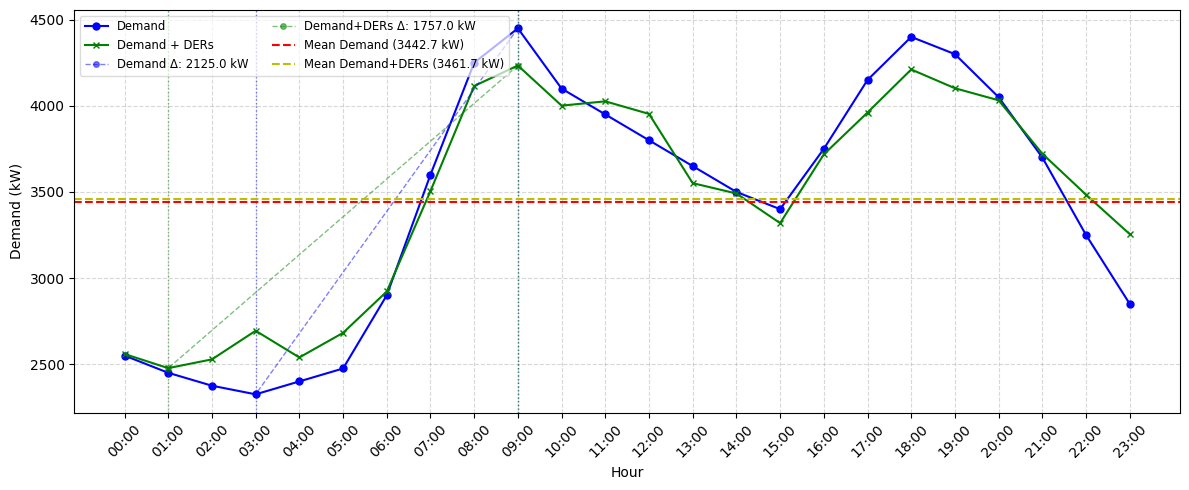

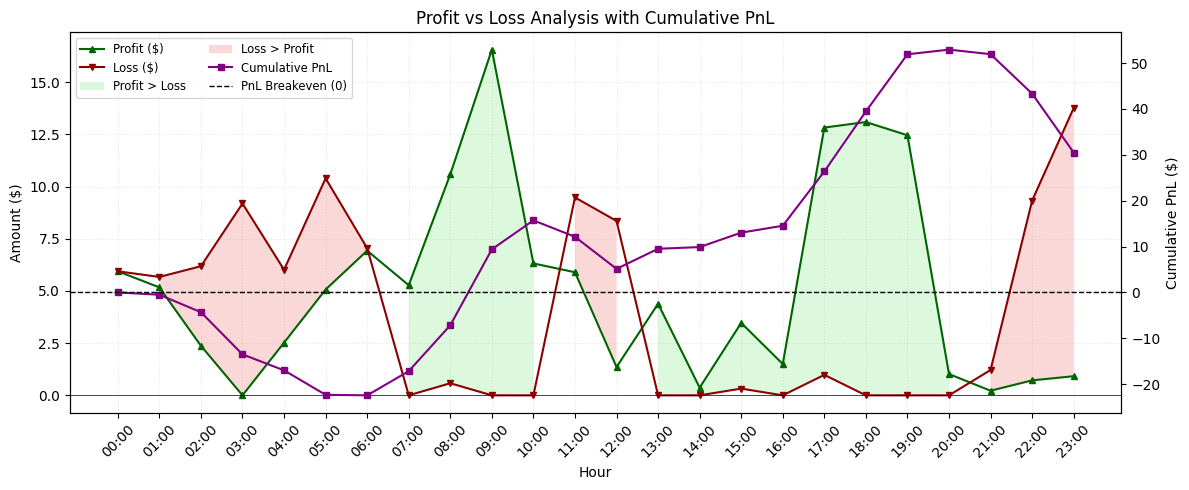

In [57]:
# Prepare the dataframe
df_k1 = df_k.copy()
df_k1['Projected_Load_kW_1'] = (df_k1['Projected_Load_kW'] / 2).astype(int)
df_k1['Grid_to_DERs'] = total_energy_per_time_charge  # Charge
df_k1['DERs_to_Grid'] = total_energy_per_time_discharge  # Discharge
df_k1['Demand_plus_DERs'] = (df_k1['Projected_Load_kW_1'] + df_k1['Grid_to_DERs'] - df_k1['DERs_to_Grid']).astype(int)
df_k1['PnL_cum'] = np.cumsum(df_k1['PnL($/kWh)'])
df_k1['Profit ($)'] = weighted_energy_value_discharge
df_k1['Loss ($)'] = weighted_energy_value_charge

# Extract the data
hours = df_k1.index
demand = df_k1['Projected_Load_kW_1']
demand_plus_ders = df_k1['Demand_plus_DERs']
mean_demand = demand.mean()
mean_demand_plus_ders = demand_plus_ders.mean()

#############################################
# FIRST PLOT: Demand vs Demand+DERs only (no PnL)
#############################################
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Demand and Demand + DERs
ax1.plot(hours, demand, label='Demand', marker='o', color='blue', markersize=5)
ax1.plot(hours, demand_plus_ders, label='Demand + DERs', marker='x', color='green', markersize=5)

# Find peaks and troughs for Demand
demand_max_idx = demand.idxmax()
demand_min_idx = demand.idxmin()
demand_max_val = demand.max()
demand_min_val = demand.min()

# Find peaks and troughs for Demand + DERs
ders_max_idx = demand_plus_ders.idxmax()
ders_min_idx = demand_plus_ders.idxmin()
ders_max_val = demand_plus_ders.max()
ders_min_val = demand_plus_ders.min()

# Add vertical lines and difference indicators for Demand
ax1.axvline(x=demand_max_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=demand_min_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.plot([demand_max_idx, demand_min_idx], [demand_max_val, demand_min_val],
        'bo--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Demand Δ: {demand_max_val-demand_min_val:.1f} kW')

# Add vertical lines and difference indicators for Demand + DERs
ax1.axvline(x=ders_max_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=ders_min_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.plot([ders_max_idx, ders_min_idx], [ders_max_val, ders_min_val],
        'go--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Demand+DERs Δ: {ders_max_val-ders_min_val:.1f} kW')

# Add mean reference lines
ax1.axhline(y=mean_demand, color='r', linestyle='--', label=f'Mean Demand ({mean_demand:.1f} kW)')
ax1.axhline(y=mean_demand_plus_ders, color='y', linestyle='--', label=f'Mean Demand+DERs ({mean_demand_plus_ders:.1f} kW)')

# Customize primary axis
ax1.set_xlabel('Hour')
ax1.set_ylabel('Demand (kW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize='small', framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

#############################################
# SECOND PLOT: Profit/Loss with Cumulative PnL
#############################################
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Profit/Loss lines on primary axis
ax1.plot(hours, df_k1['Profit ($)'], label='Profit ($)', color='darkgreen', linewidth=1.5, marker='^', markersize=4)
ax1.plot(hours, df_k1['Loss ($)'], label='Loss ($)', color='darkred', linewidth=1.5, marker='v', markersize=4)

# Fill between the lines
ax1.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Profit ($)'] > df_k1['Loss ($)']),
               facecolor='lightgreen',
               alpha=0.3,
               label='Profit > Loss')

ax1.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Loss ($)'] > df_k1['Profit ($)']),
               facecolor='lightcoral',
               alpha=0.3,
               label='Loss > Profit')

# Add zero line
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Create secondary axis for Cumulative PnL
ax2 = ax1.twinx()
ax2.plot(hours, df_k1['PnL_cum'], label='Cumulative PnL', color='purple', linestyle='-', marker='s', markersize=5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, label='PnL Breakeven (0)')
ax2.set_ylabel('Cumulative PnL ($)')

# Formatting
ax1.set_title('Profit vs Loss Analysis with Cumulative PnL')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Amount ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle=':', alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           fontsize='small', 
           framealpha=0.8,
           ncol=2)

plt.tight_layout()
plt.show()

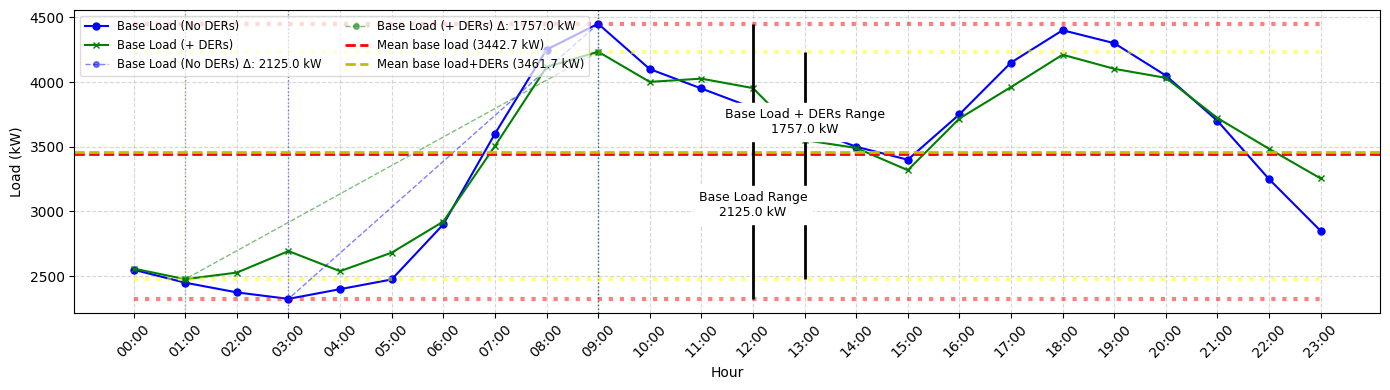

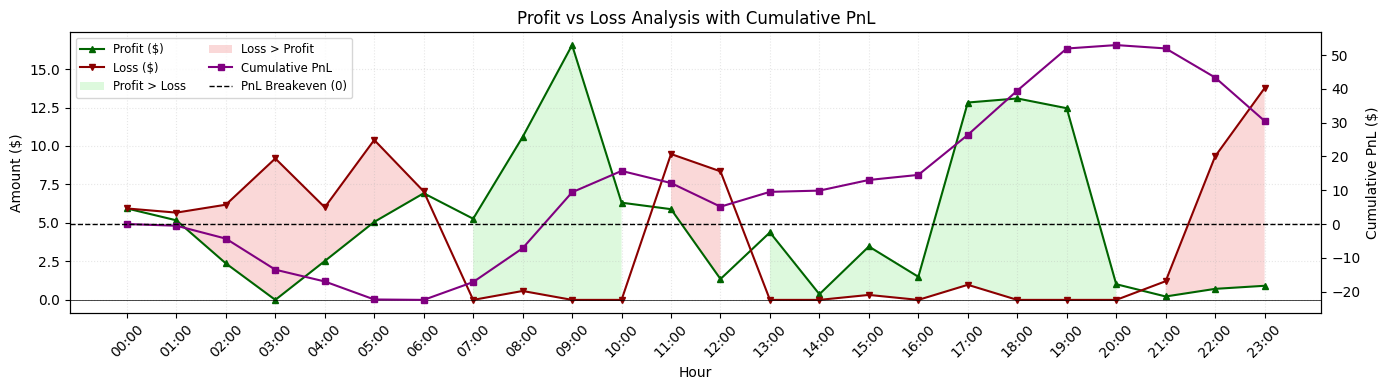

In [77]:
# Prepare the dataframe
df_k1 = df_k.copy()
df_k1['Projected_Load_kW_1'] = (df_k1['Projected_Load_kW'] / 2).astype(int)
df_k1['Grid_to_DERs'] = total_energy_per_time_charge  # Charge
df_k1['DERs_to_Grid'] = total_energy_per_time_discharge  # Discharge
df_k1['Demand_plus_DERs'] = (df_k1['Projected_Load_kW_1'] + df_k1['Grid_to_DERs'] - df_k1['DERs_to_Grid']).astype(int)
df_k1['PnL_cum'] = np.cumsum(df_k1['PnL($/kWh)'])
df_k1['Profit ($)'] = weighted_energy_value_discharge
df_k1['Loss ($)'] = weighted_energy_value_charge

# Extract the data
hours = df_k1.index
demand = df_k1['Projected_Load_kW_1']
demand_plus_ders = df_k1['Demand_plus_DERs']
mean_demand = demand.mean()
mean_demand_plus_ders = demand_plus_ders.mean()

#############################################
# FIRST PLOT: Demand vs Demand+DERs with range lines
#############################################
fig, ax1 = plt.subplots(figsize=(14, 4))  # Increased height for better visibility

# Plot Demand and Demand + DERs
ax1.plot(hours, demand, label='Base Load (No DERs)', marker='o', color='blue', markersize=5)
ax1.plot(hours, demand_plus_ders, label='Base Load (+ DERs)', marker='x', color='green', markersize=5)

# Find peaks and troughs for Demand
demand_max_idx = demand.idxmax()
demand_min_idx = demand.idxmin()
demand_max_val = demand.max()
demand_min_val = demand.min()

# Find peaks and troughs for Demand + DERs
ders_max_idx = demand_plus_ders.idxmax()
ders_min_idx = demand_plus_ders.idxmin()
ders_max_val = demand_plus_ders.max()
ders_min_val = demand_plus_ders.min()

# Add vertical lines for Demand
ax1.axvline(x=demand_max_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=demand_min_idx, color='blue', linestyle=':', alpha=0.5, linewidth=1)

# Add vertical lines for Demand + DERs
ax1.axvline(x=ders_max_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)
ax1.axvline(x=ders_min_idx, color='green', linestyle=':', alpha=0.5, linewidth=1)

# Add FOUR horizontal dotted lines showing the ranges
# For Demand (red lines)
ax1.hlines(y=demand_max_val, xmin=hours[0], xmax=hours[-1], 
           colors='red', linestyles='dotted', alpha=0.5, linewidth=3)
ax1.hlines(y=demand_min_val, xmin=hours[0], xmax=hours[-1], 
           colors='red', linestyles='dotted', alpha=0.5, linewidth=3)

# For Demand+DERs (yellow lines)
ax1.hlines(y=ders_max_val, xmin=hours[0], xmax=hours[-1], 
           colors='yellow', linestyles='dotted', alpha=0.5, linewidth=3)
ax1.hlines(y=ders_min_val, xmin=hours[0], xmax=hours[-1], 
           colors='yellow', linestyles='dotted', alpha=0.5, linewidth=3)

# Add connecting lines with labels showing the delta values
ax1.plot([demand_max_idx, demand_min_idx], [demand_max_val, demand_min_val],
        'bo--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load (No DERs) Δ: {demand_max_val-demand_min_val:.1f} kW')

ax1.plot([ders_max_idx, ders_min_idx], [ders_max_val, ders_min_val],
        'go--', alpha=0.5, linewidth=1, markersize=4,
        label=f'Base Load (+ DERs) Δ: {ders_max_val-ders_min_val:.1f} kW')

# Add mean reference lines
ax1.axhline(y=mean_demand, color='r', linestyle='--', linewidth=2, label=f'Mean base load ({mean_demand:.1f} kW)')
ax1.axhline(y=mean_demand_plus_ders, color='y', linestyle='--', linewidth=2, label=f'Mean base load+DERs ({mean_demand_plus_ders:.1f} kW)')

# Add vertical lines between the highest and lowest lines
if hasattr(hours, 'hour'):  # Check if it's datetime-like
    mid_point = hours[len(hours)//2]
    offset_point = hours[len(hours)//2 + 1] if len(hours) > 1 else mid_point
else:
    mid_point = len(hours)//2
    offset_point = len(hours)//2 + 1 if len(hours) > 1 else mid_point

# # Vertical line for Demand range (red lines)
# ax1.vlines(x=mid_point, ymin=demand_min_val, ymax=demand_max_val, 
#            colors='black', linestyles='solid', linewidth=2)
# ax1.text(mid_point, (demand_min_val + demand_max_val)/2, 
#          f'Base Load Range\n{demand_max_val-demand_min_val:.1f} kW', 
#          ha='center', va='center', backgroundcolor='white')

# # Vertical line for Demand+DERs range (yellow lines)
# ax1.vlines(x=offset_point, ymin=ders_min_val, ymax=ders_max_val, 
#            colors='black', linestyles='solid', linewidth=2)
# ax1.text(offset_point, (ders_min_val + ders_max_val)/2, 
#          f'Base Load + DERs Range\n{ders_max_val-ders_min_val:.1f} kW', 
#          ha='center', va='center', backgroundcolor='white')

# Vertical line for Demand range (red lines)
demand_range_mid = (demand_min_val + demand_max_val) / 2
ax1.vlines(x=mid_point, ymin=demand_min_val, ymax=demand_max_val, 
           colors='black', linestyles='solid', linewidth=2)
ax1.text(
    mid_point, demand_range_mid - (0.1 * demand_range_mid),  # Offset downward
    f'Base Load Range\n{demand_max_val-demand_min_val:.1f} kW', 
    ha='center', va='center', 
    backgroundcolor='white',
    fontsize=9
)

# Vertical line for Demand+DERs range (yellow lines)
ders_range_mid = (ders_min_val + ders_max_val) / 2
ax1.vlines(x=offset_point, ymin=ders_min_val, ymax=ders_max_val, 
           colors='black', linestyles='solid', linewidth=2)
ax1.text(
    offset_point, ders_range_mid + (0.1 * ders_range_mid),  # Offset upward
    f'Base Load + DERs Range\n{ders_max_val-ders_min_val:.1f} kW', 
    ha='center', va='center', 
    backgroundcolor='white',
    fontsize=9
)

# Customize primary axis
ax1.set_xlabel('Hour')
ax1.set_ylabel('Load (kW)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize='small', framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

#############################################
# SECOND PLOT: Profit/Loss with Cumulative PnL
#############################################
fig, ax1 = plt.subplots(figsize=(14, 4))

# Plot Profit/Loss lines on primary axis
ax1.plot(hours, df_k1['Profit ($)'], label='Profit ($)', color='darkgreen', linewidth=1.5, marker='^', markersize=4)
ax1.plot(hours, df_k1['Loss ($)'], label='Loss ($)', color='darkred', linewidth=1.5, marker='v', markersize=4)

# Fill between the lines
ax1.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Profit ($)'] > df_k1['Loss ($)']),
               facecolor='lightgreen',
               alpha=0.3,
               label='Profit > Loss')

ax1.fill_between(hours,
               df_k1['Profit ($)'],
               df_k1['Loss ($)'],
               where=(df_k1['Loss ($)'] > df_k1['Profit ($)']),
               facecolor='lightcoral',
               alpha=0.3,
               label='Loss > Profit')

# Add zero line
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Create secondary axis for Cumulative PnL
ax2 = ax1.twinx()
ax2.plot(hours, df_k1['PnL_cum'], label='Cumulative PnL', color='purple', linestyle='-', marker='s', markersize=5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, label='PnL Breakeven (0)')
ax2.set_ylabel('Cumulative PnL ($)')

# Formatting
ax1.set_title('Profit vs Loss Analysis with Cumulative PnL')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Amount ($)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, which='both', linestyle=':', alpha=0.3)

# Combine legends - using frameon instead of framecolor
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', 
           fontsize='small', 
           frameon=True,
           facecolor='white',
           framealpha=0.8,
           ncol=2)

plt.tight_layout()
plt.show()

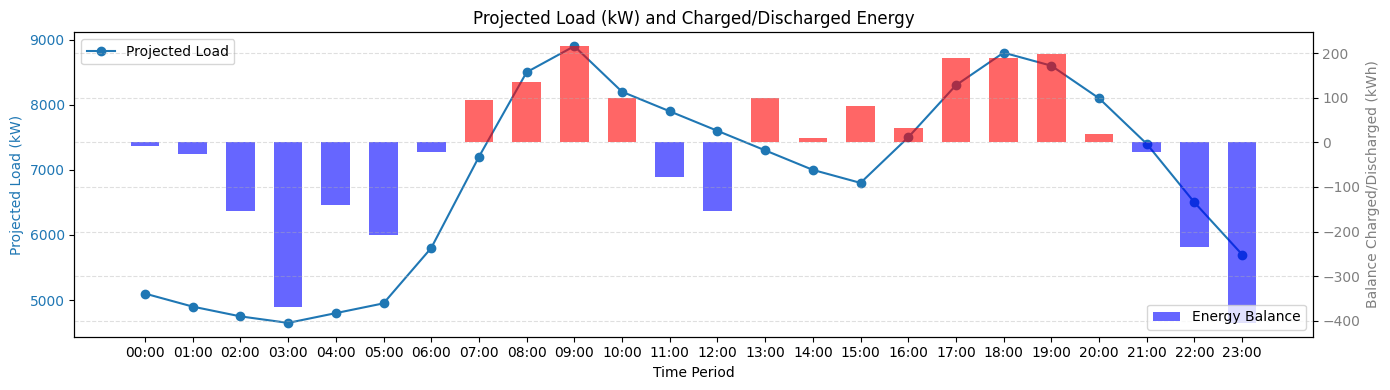

In [60]:
# Prepare bar colors based on sign
bar_colors = df_k["Balance_discharged_charged(kWh)"].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Buy/Sell price lines
ax1.set_title("Projected Load (kW) and Charged/Discharged Energy")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Projected Load (kW)", color='tab:blue')
ax1.plot(df_k.index, df_k["Projected_Load_kW"], label="Projected Load", marker='o', color='tab:blue')
# ax1.plot(df_k.index, df_k["Sell_Price"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for bar plot
ax2 = ax1.twinx()
ax2.set_ylabel("Balance Charged/Discharged (kWh)", color='tab:gray')
ax2.bar(
    df_k.index,
    df_k["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6,
    label="Energy Balance"
)
ax2.tick_params(axis='y', labelcolor='tab:gray')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

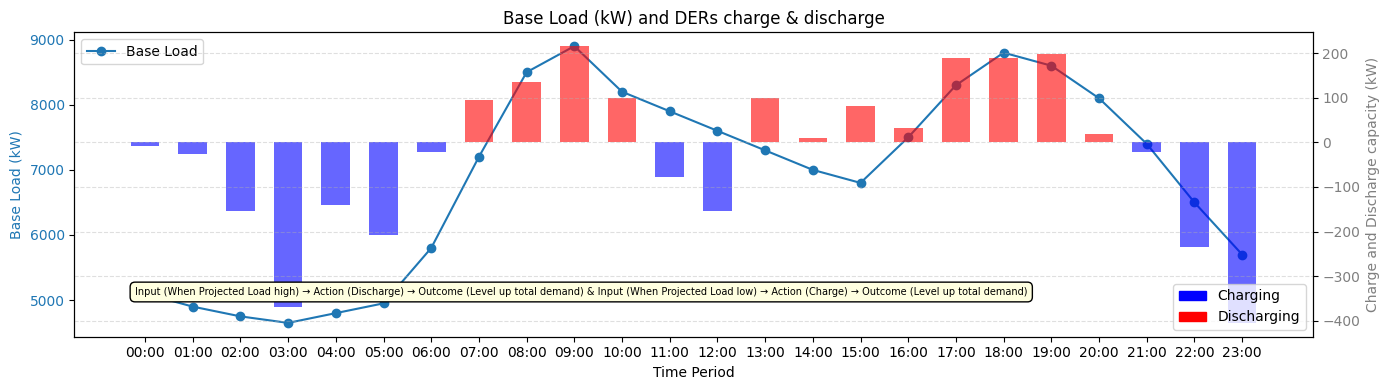

In [70]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Prepare bar colors
bar_colors = df_k["Balance_discharged_charged(kWh)"].apply(
    lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Line: Projected Load
ax1.set_title("Base Load (kW) and DERs charge & discharge")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Base Load (kW)", color='tab:blue')
ax1.plot(df_k.index, df_k["Projected_Load_kW"], label="Base Load", marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Bars: Energy Balance
ax2 = ax1.twinx()
ax2.set_ylabel("Charge and Discharge capacity (kW)", color='tab:gray')
ax2.bar(
    df_k.index,
    df_k["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6
)
ax2.tick_params(axis='y', labelcolor='tab:gray')

# Custom legend for bar colors
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label='Charging'),
    Patch(facecolor='red', edgecolor='red', label='Discharging')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Add explanation box to the plot
textstr = "Input (When Projected Load high) → Action (Discharge) → Outcome (Level up total demand) & Input (When Projected Load low) → Action (Charge) → Outcome (Level up total demand)"

# Add box to the plot (in figure coordinates)
plt.gcf().text(
    0.10, 0.25, textstr,
    fontsize=7,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.show()

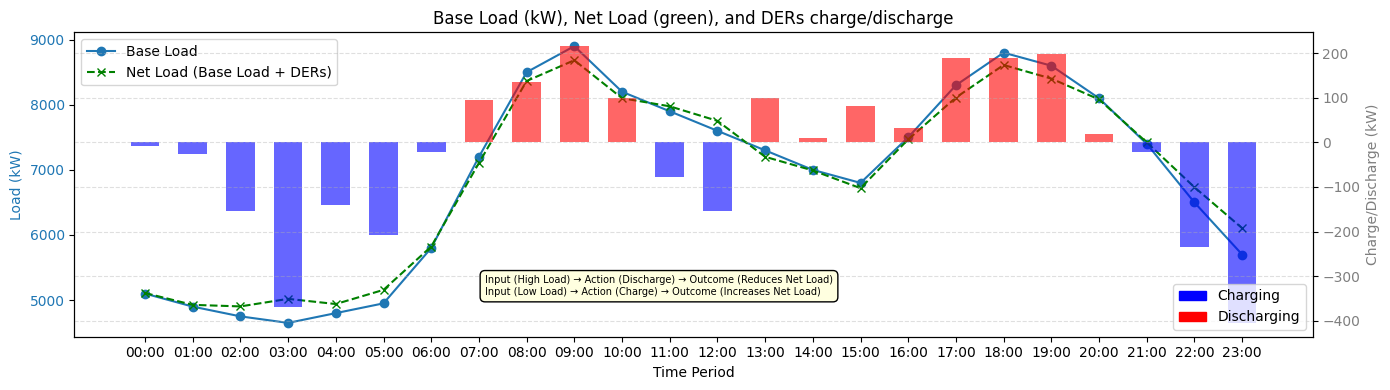

In [75]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Prepare bar colors
bar_colors = df_k["Balance_discharged_charged(kWh)"].apply(
    lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray')
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Line: Projected Load (blue)
ax1.set_title("Base Load (kW), Net Load (green), and DERs charge/discharge")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Load (kW)", color='tab:blue')
ax1.plot(df_k.index, df_k["Projected_Load_kW"], label="Base Load", marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Line: Net Load (green) = Projected Load + Balance
ax1.plot(
    df_k.index,
    df_k["Projected_Load_kW"] - df_k["Balance_discharged_charged(kWh)"],
    label="Net Load (Base Load + DERs)",
    linestyle='--',
    color='green',
    marker='x'
)
ax1.legend(loc="upper left")

# Bars: Energy Balance (red/blue)
ax2 = ax1.twinx()
ax2.set_ylabel("Charge/Discharge (kW)", color='tab:gray')
ax2.bar(
    df_k.index,
    df_k["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6
)
ax2.tick_params(axis='y', labelcolor='tab:gray')

# Custom legend for bar colors
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label='Charging'),
    Patch(facecolor='red', edgecolor='red', label='Discharging')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Add explanation box
textstr = (
    "Input (High Load) → Action (Discharge) → Outcome (Reduces Net Load)\n"
    "Input (Low Load) → Action (Charge) → Outcome (Increases Net Load)"
)
plt.gcf().text(
    0.35, 0.25, textstr,
    fontsize=7,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.show()

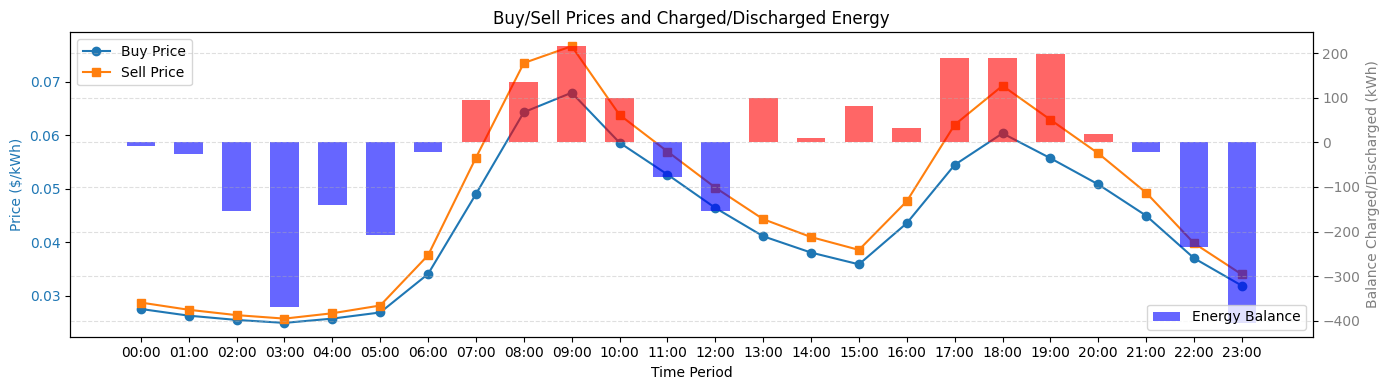

In [62]:
# Prepare bar colors based on sign
bar_colors = df_k["Balance_discharged_charged(kWh)"].apply(lambda x: 'red' if x > 0 else ('blue' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Buy/Sell price lines
ax1.set_title("Buy/Sell Prices and Charged/Discharged Energy")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df_k.index, df_k["Buy_Price"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df_k.index, df_k["Sell_Price"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for bar plot
ax2 = ax1.twinx()
ax2.set_ylabel("Balance Charged/Discharged (kWh)", color='tab:gray')
ax2.bar(
    df_k.index,
    df_k["Balance_discharged_charged(kWh)"],
    color=bar_colors,
    alpha=0.6,
    width=0.6,
    label="Energy Balance"
)
ax2.tick_params(axis='y', labelcolor='tab:gray')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

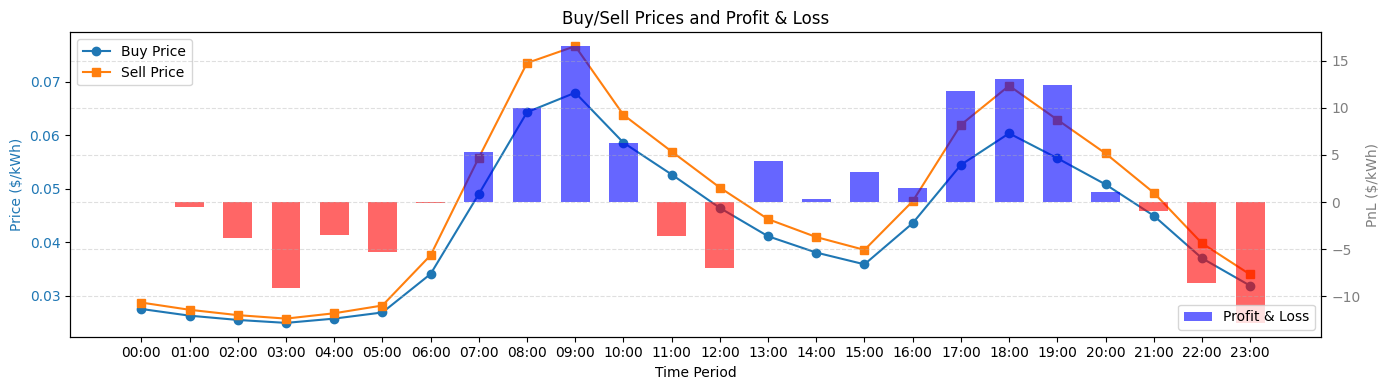

In [63]:
# Define bar colors based on PnL sign
pnl_colors = df_k["PnL($/kWh)"].apply(lambda x: 'blue' if x > 0 else ('red' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Buy/Sell price lines
ax1.set_title("Buy/Sell Prices and Profit & Loss")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df_k.index, df_k["Buy_Price"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df_k.index, df_k["Sell_Price"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for PnL bars
ax2 = ax1.twinx()
ax2.set_ylabel("PnL ($/kWh)", color='tab:gray')
ax2.bar(
    df_k.index,
    df_k["PnL($/kWh)"],
    color=pnl_colors,
    alpha=0.6,
    width=0.6,
    label="Profit & Loss"
)
ax2.tick_params(axis='y', labelcolor='tab:gray')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

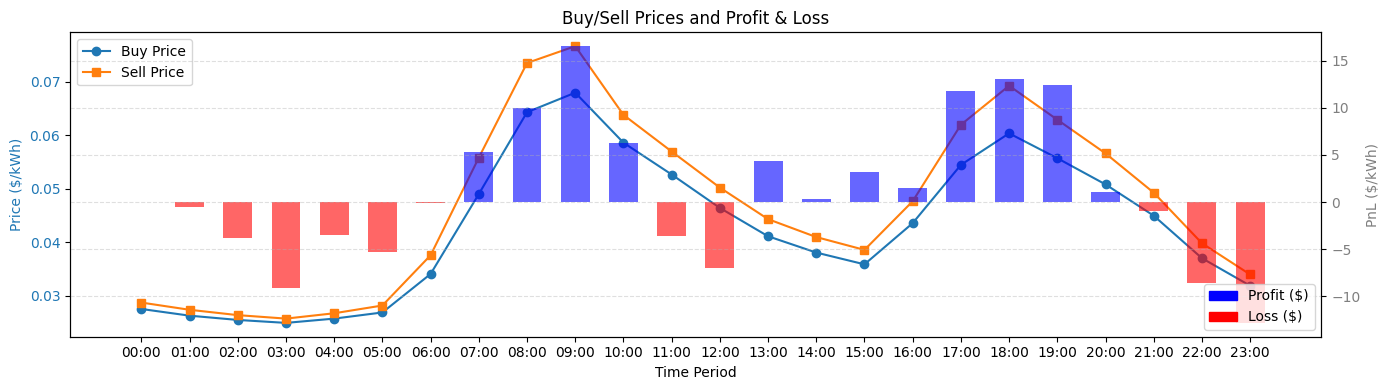

In [64]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Define bar colors based on PnL sign
pnl_colors = df_k["PnL($/kWh)"].apply(lambda x: 'blue' if x > 0 else ('red' if x < 0 else 'gray'))

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))

# Buy/Sell price lines
ax1.set_title("Buy/Sell Prices and Profit & Loss")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(df_k.index, df_k["Buy_Price"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(df_k.index, df_k["Sell_Price"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Secondary axis for PnL bars
ax2 = ax1.twinx()
ax2.set_ylabel("PnL ($/kWh)", color='tab:gray')
ax2.bar(
    df_k.index,
    df_k["PnL($/kWh)"],
    color=pnl_colors,
    alpha=0.6,
    width=0.6
)
ax2.tick_params(axis='y', labelcolor='tab:gray')

# Custom legend for PnL colors
legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label='Profit ($)'),
    Patch(facecolor='red', edgecolor='red', label='Loss ($)')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [65]:
print("PnL: $", PnL.sum())
print("BEE: kWh", BEE.sum())

PnL: $ 30.500550000000004
BEE: kWh -459.0


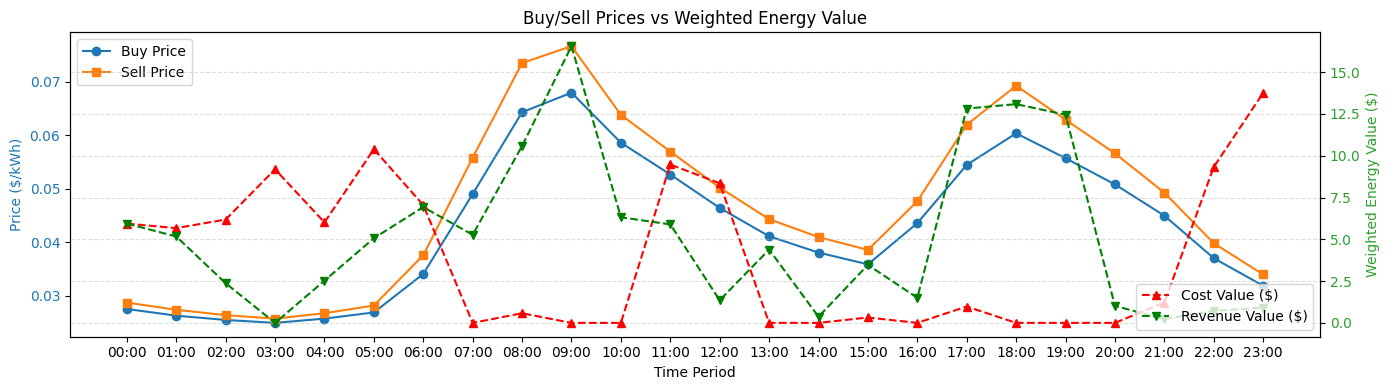

In [66]:
# Time index (same as df_k)
time_periods = df_k.index

# Plot
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.set_title("Buy/Sell Prices vs Weighted Energy Value")
ax1.set_xlabel("Time Period")

# Left y-axis: Buy and Sell Prices
ax1.set_ylabel("Price ($/kWh)", color='tab:blue')
ax1.plot(time_periods, df_k["Buy_Price"], label="Buy Price", marker='o', color='tab:blue')
ax1.plot(time_periods, df_k["Sell_Price"], label="Sell Price", marker='s', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc="upper left")

# Right y-axis: Weighted energy cost and revenue
ax2 = ax1.twinx()
ax2.set_ylabel("Weighted Energy Value ($)", color='tab:green')
ax2.plot(time_periods, weighted_energy_value_charge, label="Cost Value ($)", marker='^', linestyle='--', color='red')
ax2.plot(time_periods, weighted_energy_value_discharge, label="Revenue Value ($)", marker='v', linestyle='--', color='green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

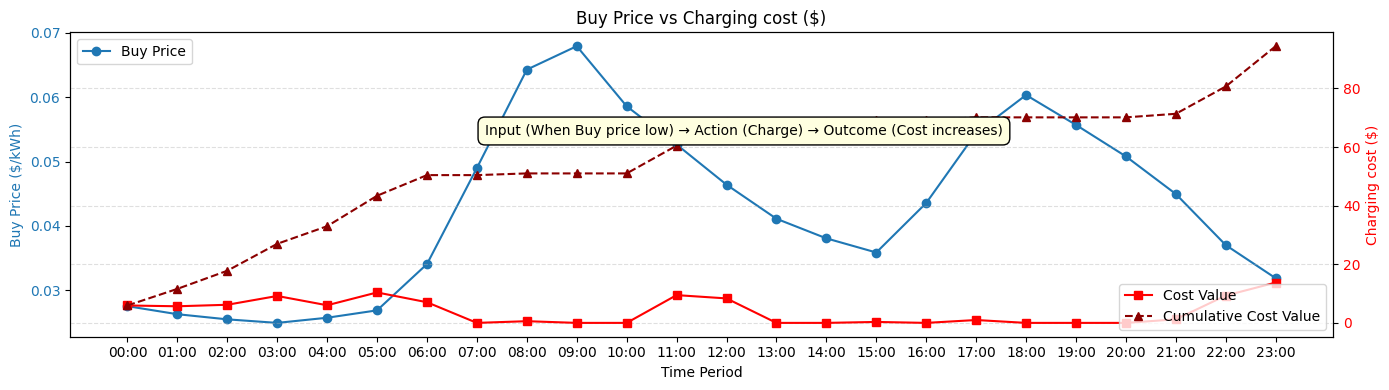

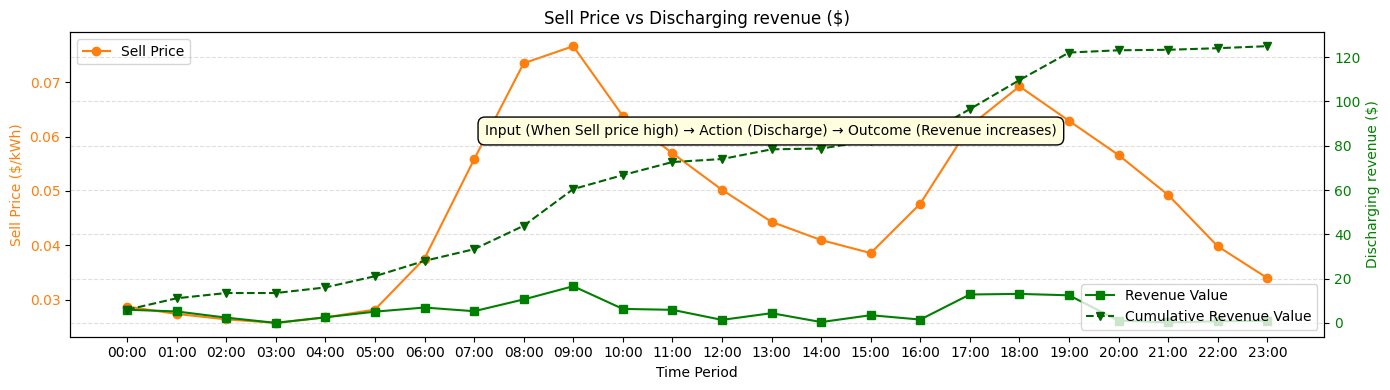

In [67]:
# Time periods (assumed to match df_k)
time_periods = df_k.index

# --- Plot 1: Buy Price vs Weighted Energy Charged ---
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.set_title("Buy Price vs Charging cost ($)")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Buy Price ($/kWh)", color='tab:blue')
ax1.plot(time_periods, df_k["Buy_Price"], marker='o', label='Buy Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Right y-axis: weighted charge + cumulative
ax2 = ax1.twinx()
ax2.set_ylabel("Charging cost ($)", color='red')
ax2.plot(time_periods, weighted_energy_value_charge, marker='s', label='Cost Value', color='red')
ax2.plot(time_periods, np.cumsum(weighted_energy_value_charge), marker='^', linestyle='--', label='Cumulative Cost Value', color='darkred')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right')


plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Add explanation box to the plot
textstr = "Input (When Buy price low) → Action (Charge) → Outcome (Cost increases)"

# Add box to the plot (in figure coordinates)
plt.gcf().text(
    0.35, 0.65, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.show()


# --- Plot 2: Sell Price vs Weighted Energy Discharged ---
fig, ax3 = plt.subplots(figsize=(14, 4))
ax3.set_title("Sell Price vs Discharging revenue ($)")
ax3.set_xlabel("Time Period")
ax3.set_ylabel("Sell Price ($/kWh)", color='tab:orange')
ax3.plot(time_periods, df_k["Sell_Price"], marker='o', label='Sell Price', color='tab:orange')
ax3.tick_params(axis='y', labelcolor='tab:orange')
ax3.legend(loc='upper left')


# Right y-axis: weighted discharge + cumulative
ax4 = ax3.twinx()
ax4.set_ylabel("Discharging revenue ($)", color='green')
ax4.plot(time_periods, weighted_energy_value_discharge, marker='s', label='Revenue Value', color='green')
ax4.plot(time_periods, np.cumsum(weighted_energy_value_discharge), marker='v', linestyle='--', label='Cumulative Revenue Value', color='darkgreen')
ax4.tick_params(axis='y', labelcolor='green')
ax4.legend(loc='lower right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Add explanation box to the plot
textstr = "Input (When Sell price high) → Action (Discharge) → Outcome (Revenue increases)"

# Add box to the plot (in figure coordinates)
plt.gcf().text(
    0.35, 0.65, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.show()

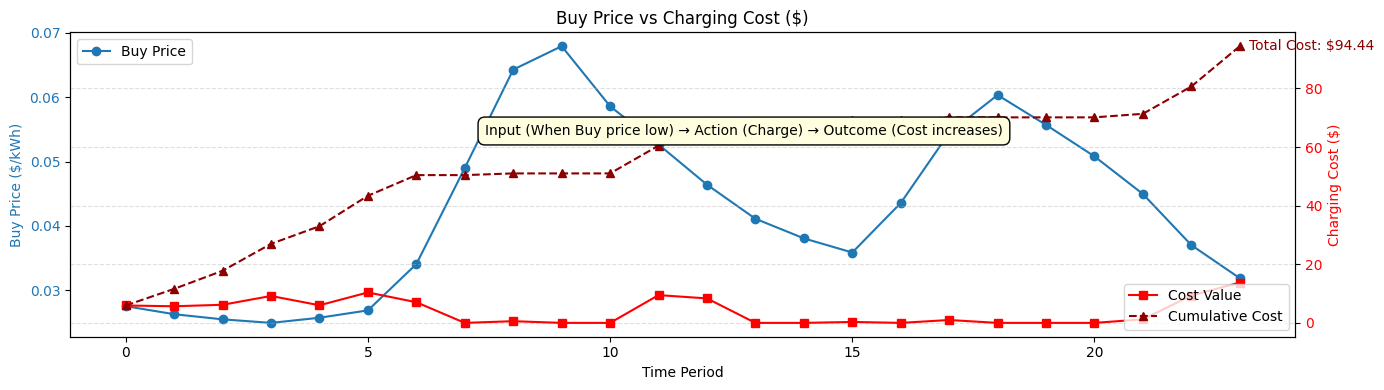

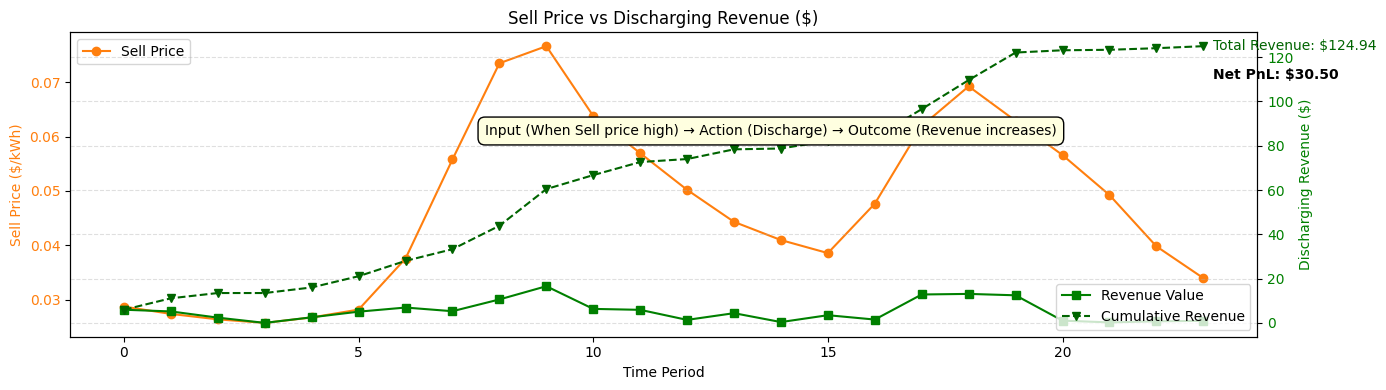

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Assumed inputs (you must define these before this code) ---
# df_k: DataFrame with columns 'Buy_Price', 'Sell_Price', 'Projected_Load_kW'
# weighted_energy_value_charge: array with cost per timestamp
# weighted_energy_value_discharge: array with revenue per timestamp

# Ensure numeric time axis
time_periods = np.arange(len(df_k))  # [0, 1, 2, ..., N-1]

# --- Plot 1: Buy Price vs Charging Cost ---
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.set_title("Buy Price vs Charging Cost ($)")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Buy Price ($/kWh)", color='tab:blue')
ax1.plot(time_periods, df_k["Buy_Price"], marker='o', label='Buy Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Right y-axis for cost and cumulative cost
ax2 = ax1.twinx()
ax2.set_ylabel("Charging Cost ($)", color='red')
ax2.plot(time_periods, weighted_energy_value_charge, marker='s', label='Cost Value', color='red')
ax2.plot(time_periods, np.cumsum(weighted_energy_value_charge), marker='^', linestyle='--', label='Cumulative Cost', color='darkred')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right')

# Annotate final cumulative cost
final_cost = np.cumsum(weighted_energy_value_charge)[-1]
ax2.text(
    time_periods[-1] + 0.2,
    final_cost,
    f"Total Cost: ${final_cost:.2f}",
    color='darkred',
    fontsize=10,
    va='center'
)

# Explanation box
textstr = "Input (When Buy price low) → Action (Charge) → Outcome (Cost increases)"
plt.gcf().text(
    0.35, 0.65, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# --- Plot 2: Sell Price vs Discharging Revenue ---
fig, ax3 = plt.subplots(figsize=(14, 4))
ax3.set_title("Sell Price vs Discharging Revenue ($)")
ax3.set_xlabel("Time Period")
ax3.set_ylabel("Sell Price ($/kWh)", color='tab:orange')
ax3.plot(time_periods, df_k["Sell_Price"], marker='o', label='Sell Price', color='tab:orange')
ax3.tick_params(axis='y', labelcolor='tab:orange')
ax3.legend(loc='upper left')

# Right y-axis for revenue and cumulative revenue
ax4 = ax3.twinx()
ax4.set_ylabel("Discharging Revenue ($)", color='green')
ax4.plot(time_periods, weighted_energy_value_discharge, marker='s', label='Revenue Value', color='green')
ax4.plot(time_periods, np.cumsum(weighted_energy_value_discharge), marker='v', linestyle='--', label='Cumulative Revenue', color='darkgreen')
ax4.tick_params(axis='y', labelcolor='green')
ax4.legend(loc='lower right')

# Annotate final cumulative revenue
final_revenue = np.cumsum(weighted_energy_value_discharge)[-1]
ax4.text(
    time_periods[-1] + 0.2,
    final_revenue,
    f"Total Revenue: ${final_revenue:.2f}",
    color='darkgreen',
    fontsize=10,
    va='center'
)

# Calculate and annotate Net PnL
net_pnl = final_revenue - final_cost
ax4.text(
    time_periods[-1] + 0.2,
    final_revenue - 10,  # adjust as needed
    f"Net PnL: ${net_pnl:.2f}",
    color='black',
    fontsize=10,
    fontweight='bold',
    va='top'
)

# Explanation box
textstr = "Input (When Sell price high) → Action (Discharge) → Outcome (Revenue increases)"
plt.gcf().text(
    0.35, 0.65, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

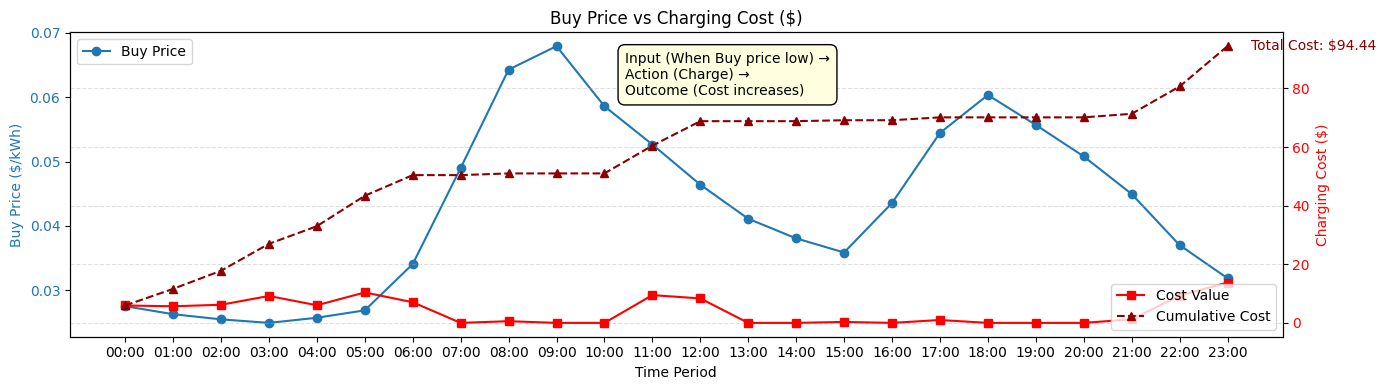

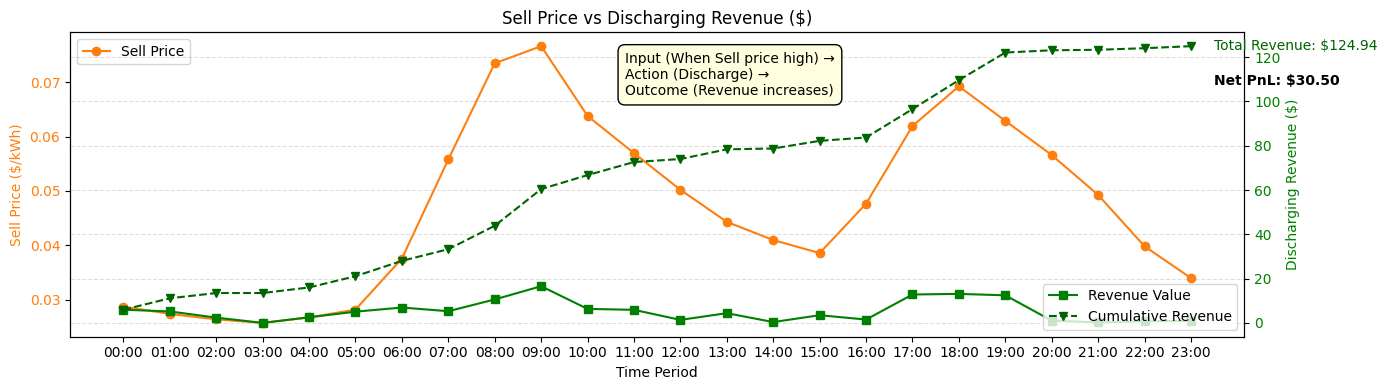

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assume df_k is already defined and has:
# - df_k["Buy_Price"], df_k["Sell_Price"]
# - weighted_energy_value_charge
# - weighted_energy_value_discharge

# ✔ If your df_k.index is datetime, convert it to "HH:MM" format
time_periods = df_k.index.strftime("%H:%M") if isinstance(df_k.index[0], pd.Timestamp) else df_k.index

# --- Plot 1: Buy Price vs Charging Cost ---
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.set_title("Buy Price vs Charging Cost ($)")
ax1.set_xlabel("Time Period")
ax1.set_ylabel("Buy Price ($/kWh)", color='tab:blue')
ax1.plot(time_periods, df_k["Buy_Price"], marker='o', label='Buy Price', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Right y-axis for cost and cumulative cost
ax2 = ax1.twinx()
ax2.set_ylabel("Charging Cost ($)", color='red')
ax2.plot(time_periods, weighted_energy_value_charge, marker='s', label='Cost Value', color='red')
ax2.plot(time_periods, np.cumsum(weighted_energy_value_charge), marker='^', linestyle='--', label='Cumulative Cost', color='darkred')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right')

# Annotate final cumulative cost
final_cost = np.cumsum(weighted_energy_value_charge)[-1]
ax2.text(
    len(time_periods)-0.5, final_cost,
    f"Total Cost: ${final_cost:.2f}",
    color='darkred', fontsize=10, va='center'
)

# Explanation box
# textstr = "Input (When Buy price low) → Action (Charge) → Outcome (Cost increases)"

# Explanation box
textstr = ("Input (When Buy price low) →\n" 
"Action (Charge) →\n"
"Outcome (Cost increases)")

plt.gcf().text(
    0.45, 0.75, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# --- Plot 2: Sell Price vs Discharging Revenue ---
fig, ax3 = plt.subplots(figsize=(14, 4))
ax3.set_title("Sell Price vs Discharging Revenue ($)")
ax3.set_xlabel("Time Period")
ax3.set_ylabel("Sell Price ($/kWh)", color='tab:orange')
ax3.plot(time_periods, df_k["Sell_Price"], marker='o', label='Sell Price', color='tab:orange')
ax3.tick_params(axis='y', labelcolor='tab:orange')
ax3.legend(loc='upper left')

# Right y-axis for revenue and cumulative revenue
ax4 = ax3.twinx()
ax4.set_ylabel("Discharging Revenue ($)", color='green')
ax4.plot(time_periods, weighted_energy_value_discharge, marker='s', label='Revenue Value', color='green')
ax4.plot(time_periods, np.cumsum(weighted_energy_value_discharge), marker='v', linestyle='--', label='Cumulative Revenue', color='darkgreen')
ax4.tick_params(axis='y', labelcolor='green')
ax4.legend(loc='lower right')

# Annotate final cumulative revenue
final_revenue = np.cumsum(weighted_energy_value_discharge)[-1]
ax4.text(
    len(time_periods)-0.5, final_revenue,
    f"Total Revenue: ${final_revenue:.2f}",
    color='darkgreen', fontsize=10, va='center'
)

# Net Profit/Loss
net_pnl = final_revenue - final_cost
ax4.text(
    len(time_periods)-0.5, final_revenue - 0.1 * abs(final_revenue),
    f"Net PnL: ${net_pnl:.2f}",
    color='black', fontsize=10, fontweight='bold', va='top'
)

# Explanation box
textstr = ("Input (When Sell price high) →\n" 
"Action (Discharge) →\n"
"Outcome (Revenue increases)")

plt.gcf().text(
    0.45, 0.75, textstr,
    fontsize=10,
    bbox=dict(facecolor='lightyellow', edgecolor='black', boxstyle='round,pad=0.5')
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()